# Does the Payout–Leverage Relationship Vary with the Interest Rate Regime?
### Industry-Level Evidence from US Non-Financial Firms, 1999–2025 — *analysis pipeline*

Milan Kalajdžić · University of Warsaw, Faculty of Economic Sciences · *Quantitative Finance MA*
Supervisor: dr hab. Piotr Boguszewski

---

Empirical pipeline for Chapters **4 (Data)**, **5 (Methodology)** and **6 (Results)**. It builds an
**industry × year panel** from Damodaran's industry datasets (1999–2025), merges macro series from **FRED**, and
estimates fixed-effects panel regressions of payout on leverage: the **leverage × rate-regime interaction** (H2),
its moderation by asset tangibility (H3) and, in change form, whether more levered industries cut dividends
more when rates rise (H1).

**Reading the notebook.** Each section starts with a short note on what it does and why; the code cells
begin with a comment block saying the same in one or two lines, and the inline comments explain the choices
(a threshold, a year that is dropped, a variable that is ranked) rather than the Python. All research choices
sit in the configuration cell of §0; the data problems they respond to are documented in §2.

**Code layout.** The reusable machinery (file readers, sample checks, estimators, multiple-testing tools, figure
style) lives in the `paylev` package in `src/`, where it is covered by the tests in `tests/`. This notebook
makes the research choices and runs the analysis from top to bottom; `scripts/run_notebook.py` reruns it.

| Section | Thesis |
|---|---|
| 0 Setup · 1 Load · 2 Filters, reconciliation and data checks | §5.6, §4.1–4.2, App. B |
| 3 FRED and the rate regime · 4 Variables | §4.1, §4.3 |
| 5 Descriptives · 6 Baseline · 7 Interaction (H2) · 8 Tangibility (H3) · 8b Dividend smoothing and H1 | §4.4, §5–6 |
| 9 Robustness · 10 Tables, verdicts, H3 fragility · 11 Figures · 12 Reproducibility | §5.5, §6, App. A/C/D |


## 0 · Setup & configuration  <span style="color:gray">(§5.6)</span>

In [1]:
# Setup: libraries, display options, the paylev package and the figure style.
# Install once with  pip install -e ".[dev]"  (see the README).

import os, warnings, sys, platform, re
from functools import partial
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")      # library chatter (pandas, linearmodels); the pipeline prints its own checks
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 70)
try:
    import paylev
except ImportError:                 # package not installed: use the copy in src/
    sys.path.insert(0, str(Path("src").resolve())); import paylev
try:
    from linearmodels.panel import PanelOLS
    HAVE_LM = True
except Exception:
    HAVE_LM = False; print("linearmodels missing -> %pip install linearmodels")
from paylev.plotting import THEMES, use as use_theme, save as save_fig, dot, runs, shade, diverging, ink_on, minus
T = use_theme(THEMES["print"], base_size=9)   # thesis figures: white page, A4 text width (6.5 in), 9 pt text
FIG_DPI = 300
print("Python", sys.version.split()[0], "| pandas", pd.__version__, "| paylev", paylev.__version__)

Python 3.11.15 | pandas 3.0.2 | paylev 1.1.0


In [2]:
# Configuration: every research choice of the analysis in one place. The data problems behind the
# data-related settings are documented in §2; changing a value here and rerunning redoes everything downstream.

# Damodaran files are searched recursively in these folders (missing folders are skipped). The tests point
# PAYLEV_DATA at fake files.
SEARCH_DIRS = os.environ["PAYLEV_DATA"].split(os.pathsep) if "PAYLEV_DATA" in os.environ else ["data", "."]

# ---- Tangibility for H3 (§4, §10)
#   "ppe_assets"     -> PP&E / total assets from dbtfund: the primary measure (the standard one, e.g. Rajan &
#                       Zingales 1995). Its definition changes twice (PPE_DEF_CHANGES): Fixed Assets/BV of Capital
#                       (1999-2012), Fixed Assets/Total Assets (2013-2015), Net PP&E/Total Assets (2016+). The files
#                       keep the old label in 2016, but the values switch then (median 0.26 -> 0.20, rank
#                       correlation with 2015 only 0.83; 2017, under the new label, lines up with 2016 at 0.99).
#                       So it enters as a percentile rank within each year, comparable across the definitions.
#   "capex_deprec"   -> Cap Ex / Depreciation            (robustness)
#   "netcapex_sales" -> Net Cap Ex / Sales                (robustness)
#   "invcap_sales"   -> 1 / (Sales / Invested Capital)   (robustness)
TANGIBILITY_PROXY = "ppe_assets"
from paylev.damodaran import CAPEX_PROXIES, DEPREC_PROXIES   # which proxies come from capex / use depreciation
PPE_DEF_CHANGES   = [2013, 2016]
# Damodaran's 2013-2015 capex files report depreciation on a different basis (industry depreciation roughly
# halves against 2012 and 2016 while capex does not), which inflates Cap Ex/Depreciation and scrambles the
# industry ranking. Proxies built from depreciation are set to missing in these years.
TANG_BREAK_YEARS = [2013, 2014, 2015]

# ---- Rate regime (§4.3.3). With 27 years the threshold picks up three separate high-rate episodes.
HIGH_RATE_RULE = "threshold"   # "threshold" (primary) or "post2022" (a 2022-2025 dummy)
FFR_THRESHOLD  = 3.0           # annual-average fed funds rate (%) at or above which a year is "high-rate"
HIKE_THRESHOLD = 0.25          # rise in the annual-average fed funds rate (pp) that makes a hiking year (H1, §8b)
RECLASS_YEAR   = 2013          # Damodaran's industry reclassification: a 2012 -> 2013 change mixes in firms moving
                               # between industries, so the change and lag models drop this year

# ---- H2 equivalence test (§9b): the largest regime effect still regarded as economically negligible, in
# payout-ratio units per 1 SD of leverage (0.05 is about one seventh of the mean payout ratio).
EQUIV_MARGIN = 0.05

# ---- FRED macro data (§3)
#   "snapshot" -> the pinned series in data/fred/fred_snapshot.csv (exactly reproducible)
#   "live"     -> download the current vintage with pandas-datareader (GDP is revised over time)
FRED_SOURCE   = "snapshot"
FRED_SNAPSHOT = Path("data/fred/fred_snapshot.csv")

# ---- Sample construction and data checks (§2)
WINSOR_P         = 0.01        # ratios are clipped at the 1st and 99th percentiles (pooled over all years)
# A ratio is undefined when its denominator is not positive (payout = dividends / net income, dividends / FCFE,
# total payout / net income, ROE = net income / book equity). Damodaran still reports values there (payout about
# zero for loss-making industries that pay dividends, an ROE whose sign contradicts net income), so they are set
# to missing. The payout as reported is kept for a robustness check (§9).
POSITIVE_DENOMINATORS = True
CROSSFILE_MIN_AGREE = 0.75     # a year in which fewer industries have divfund payout = divfcfe D/NI (within 5%)
                               # marks a faulty divfcfe file; its measures are not used in that year
CROSSFILE_ROW_TOL   = 0.25     # in the other years, a payout more than 25% away from divfcfe's D/NI is set to missing
# divfund's market cap is about 1.6x (2001) and 2.1x (2004) its neighbouring years' level; the change models of
# §8b, which scale by last year's market cap, are also run without the years that follow (2002 and 2005).
MKTCAP_BREAK_YEARS  = [2001, 2004]
# Row alignment: an industry has the same number of firms in every file of a year. In a file-year where most counts
# match divfund, a row whose count differs belongs to another industry (in wacc99 a block of rows is shifted by one)
# and that file's variables are set to missing for it. Where most counts differ, the file covers a different
# vintage of the universe and is left as it is (both reported in the alignment table).
ALIGN_MIN_SHARE = 0.5
EXCLUDE_FIN_UTIL = True        # drop financial and regulated-utility industries
MIN_YEARS_CORE   = 20          # stable core (a robustness sample): industries present in at least this many years
COVID_YEARS      = [2020, 2021]
GFC_YEARS        = [2008, 2009]   # the financial crisis, dropped in a robustness check (§9)
DK_BANDWIDTH     = 3           # lags in the Driscoll-Kraay standard errors (about T^(1/3) with 27 years)
RW_BOOT          = int(os.environ.get("PAYLEV_RW_BOOT", 9999))  # industry-cluster bootstrap draws (§10b); the
                                                                # tests use fewer
RW_SEED          = 2026        # seed of the bootstrap, so its p-values reproduce exactly

OUTDIR = Path(os.environ.get("PAYLEV_OUTDIR", "outputs")); OUTDIR.mkdir(parents=True, exist_ok=True)
print("Config OK | regime:", HIGH_RATE_RULE, "| tangibility:", TANGIBILITY_PROXY,
      "| core>=", MIN_YEARS_CORE, "yrs | FRED:", FRED_SOURCE)

Config OK | regime: threshold | tangibility: ppe_assets | core>= 20 yrs | FRED: snapshot


## 1 · Load the Damodaran datasets  <span style="color:gray">(§4.1–4.2)</span>

`divfund` (payout, ROE, market cap) · `divfcfe` (dividends, net income, FCFE, buybacks) · `wacc` (leverage
D/(D+E), tax rate) · `capex` (capex-based tangibility proxies) · `dbtfund` (PP&E / assets, book and
lease-free leverage, EBITDA / EV, capital spending).

The readers (`paylev.damodaran`) handle Damodaran's three file layouts (1999–2012 `Sheet1`; 2013–2018 `Sheet1`
with a "Date updated" stamp; 2019+ `Industry Averages`, `divfund` from 2020): they locate the industry table and
its header row, take the data year from the stamp or the filename, and match columns by keyword, because the
column names change from year to year. *Checked against every file from 1999 to 2025.*


In [3]:
# File readers from paylev.damodaran. load_year reads one data year from the five files and merges them by
# industry name (raw names; reconciliation comes in §2), with this notebook's choices fixed here.
from paylev.damodaran import (TOKENS, read_industry_sheet, pick, pick_fcfe, pick_div, data_year,
                              discover_sources, load_year)
load_year = partial(load_year, tangibility_proxy=TANGIBILITY_PROXY, positive_denominators=POSITIVE_DENOMINATORS)

In [4]:
# Find every Damodaran file and read all years into one raw frame (one row per industry name and year).
# The coverage grid shows which dataset exists for which year; a year needs at least divfund and wacc.
SOURCES = {t: discover_sources(t, SEARCH_DIRS) for t in TOKENS}
all_years = sorted(set().union(*[set(v) for v in SOURCES.values()]))
grid = pd.DataFrame({t: ["Y" if y in SOURCES[t] else "." for y in all_years] for t in SOURCES},
                    index=all_years)
grid.index.name = "year"
print(f"Coverage ({len(all_years)} years {min(all_years)}-{max(all_years)}):")
print(grid.T.to_string())

years = sorted(set(SOURCES["divfund"]) & set(SOURCES["wacc"]))
raw = pd.concat([load_year(y, SOURCES) for y in years], ignore_index=True)
print(f"\nRaw panel: {len(years)} years | {raw['industry'].nunique()} distinct names | {len(raw)} rows")
raw.head()

Coverage (27 years 1999-2025):
year    1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025
divfund    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
divfcfe    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
wacc       Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
capex      Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
dbtfund    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y



Raw panel: 27 years | 219 distinct names | 2652 rows


,industry,year,payout,roe,n_firms,mktcap,lev,tax,nf_wacc,nf_divfcfe,div_usd,ni_usd,div_to_fcfe,div_yield,nf_capex,capex_deprec,nf_dbtfund,lev_unadj,lev_book,lev_dbt,ebitda_ev,ppe_assets,capex_assets,debt_ebitda_rep,int_cov,tangibility,totpayout_ni
0,Advertising,1999,0.246424,0.134948,28,58326.4895,0.098560,0.447821,28.0,28.0,266.0,1079.0,0.214171,0.004561,28.0,0.852036,28.0,0.098560,0.469885,0.098560,0.070291,0.155017,0.061801,NaN,NaN,0.155017,NaN
1,Aerospace/Defense,1999,0.245589,0.133937,48,111866.7804,0.267524,0.348131,48.0,48.0,1455.0,5926.0,0.254460,0.013007,48.0,0.902343,48.0,0.267524,0.479951,0.267524,0.138195,0.162030,0.052059,NaN,NaN,0.162030,NaN
2,Air Transport,1999,0.052681,0.189568,42,84075.3787,0.346738,0.372312,42.0,42.0,385.0,7314.0,0.434537,0.004579,42.0,2.203980,42.0,0.346738,0.553515,0.346738,0.223271,0.591270,0.209627,NaN,NaN,0.591270,NaN
3,Alternate Energy,1999,0.118465,0.139224,5,13400.0999,NaN,NaN,NaN,5.0,55.0,461.0,0.364238,0.004104,5.0,1.849453,5.0,0.483904,0.820724,0.483904,0.097176,0.472635,0.062729,NaN,NaN,0.472635,NaN
4,Aluminum,1999,0.166057,0.092600,9,35307.2390,0.483904,0.288303,5.0,9.0,259.0,1562.0,0.447323,0.007336,9.0,1.279888,9.0,0.220551,0.410099,0.220551,0.158002,0.196418,0.097814,NaN,NaN,0.196418,NaN


## 2 · Sample construction, filters, reconciliation and data checks  <span style="color:gray">(§4.2, App. B)</span>

- Drop aggregate rows; exclude **financials and regulated utilities** (keyword list that covers every era's names).
- **Reconcile industry names** across years with a *conservative* map: spelling variants and clear one-to-one
  relabels only (an industry that was split is left alone). Merged rows sum their dollar figures and average
  their ratios.
- **Check that the files line up**: firm counts against `divfund` and, for `wacc`, the debt ratio against
  `dbtfund`; payout against dividends ÷ net income from `divfcfe`, year by year and row by row.
- Set **undefined ratios** to missing (non-positive denominators, an ROE that contradicts net income).
- Rank PP&E and capital spending **within each year** (their definitions change); winsorise the ratios; define
  the **stable core** (Appendix B).


In [5]:
# Sample construction (§2): from the raw rows to the analysis panel. In order:
#   1. aggregate rows and financial / utility industries      5. merge renamed industries (clean_sample)
#   2. the industry rename map                                 6. year-level cross-file check (faulty divfcfe years)
#   3. row alignment of the five files                         7. undefined ratios: payout, ROE
#   4. derived ratios and the row-level cross-file flag        8. ranks, winsorising and the stable core

# ---- 1. Rows that are not industries, and the industries outside the sample
AGG_ROWS = ["Total Market", "Total Market (without financials)", "Grand Total",
            "Market", "Other", "Unclassified"]
# financial and regulated-utility industries, matched as lower-case substrings of the name; the list covers the
# names of every era (e.g. "Bank (Midwest)" before 2013, "Banks (Regional)" after)
FIN_UTIL_KEYS = ["bank", "insurance", "financ", "investment", "utilit", "power", "r.e.i.t", "reit",
                 "reinsurance", "brokerage", "trust", "thrift", "securities", "electric util",
                 "natural gas (distrib", "natural gas util", "water utility", "telecom. utility",
                 "public/private equity", "real estate"]

# ---- 2. Industry names: a conservative rename map, only unambiguous cases. An industry that was split (e.g.
#         Computer Software/Svcs into Computer Software and IT Services in 2011) is left alone.
INDUSTRY_RENAME = {
    # --- spelling / punctuation / typo variants ---
    "Furn./Home Furnishings": "Furn/Home Furnishings",
    "Paper & Forest Products": "Paper/Forest Products",
    "Office Equip & Supplies": "Office Equip/Supplies",
    "Oilfield Services/Equip.": "Oilfield Svcs/Equip.",
    "Semiconductor Cap Eq": "Semiconductor Equip",
    "Semiconductor Cap Equip": "Semiconductor Equip",
    "Manuf. Housing/Rec Veh": "Manuf. Housing/RV",
    "Computer Software & Svcs": "Computer Software/Svcs",
    "Heavy Truck/Equip Makers": "Heavy Truck & Equip",
    "Natural Gas (Diversified": "Natural Gas (Div.)",
    "Natural Gas (Diversified)": "Natural Gas (Div.)",
    "Publshing & Newspapers": "Publishing & Newspapers",
    "Retail Automotive": "Retail (Automotive)",
    "Retail Building Supply": "Retail (Building Supply)",
    "Auto Parts (OEM)": "Auto Parts",
    "Auto Parts (Replacement)": "Auto Parts",
    "Trucking/Transp. Leasing": "Trucking",
    "Gold/Silver Mining": "Precious Metals",
    "Computer & Peripherals": "Computers/Peripherals",          # 1999-2001 -> 2002+
    "Healthcare Info Systems": "Healthcare Information",        # 1999-2001 -> 2002-2012
    "Foreign Electron/Entertn": "Foreign Electronics",          # 1999-2001 -> 2002-2012
    # --- clear 1:1 relabels across the 2013 reclassification ---
    "Beverage (Soft Drink)": "Beverage (Soft)",
    "Educational Services": "Education",
    "Railroad": "Transportation (Railroads)",
    "Restaurant": "Restaurant/Dining",
    "Tire & Rubber": "Rubber& Tires",
    "Metals & Mining (Div.)": "Metals & Mining",
    "Environmental": "Environmental & Waste Services",
    "Newspaper": "Publishing & Newspapers",
    "Publishing": "Publishing & Newspapers",
}

from paylev.sample import (is_fin_util, clean_sample, winsorize, check_row_alignment, check_value_agreement,
                           crossfile_agreement)
winsorize = partial(winsorize, p=WINSOR_P)

# ---- 3. Row alignment. First check: each file's firm count against divfund's for the same industry and year
#         (raw names, before reconciliation). ALIGN_VARS lists which variables come from which file, i.e. what is
#         set to missing when that file's row belongs to another industry.
_TANG_SRC = "dbtfund" if TANGIBILITY_PROXY == "ppe_assets" else "capex"
ALIGN_VARS = {"wacc": ["lev", "tax"],
              "divfcfe": ["div_usd", "ni_usd", "div_to_fcfe", "totpayout_ni", "div_yield"],
              "capex": ["capex_deprec"] + (["tangibility"] if _TANG_SRC == "capex" else []),
              "dbtfund": ["lev_unadj", "lev_dbt", "lev_book", "ebitda_ev", "ppe_assets", "capex_assets", "debt_ebitda_rep",
                          "int_cov"]
                         + (["tangibility"] if _TANG_SRC == "dbtfund" else [])}
raw, _counts = check_row_alignment(raw, ALIGN_VARS, ALIGN_MIN_SHARE, AGG_ROWS)
# Second check: wacc's D/(D+E) is the very same number as dbtfund's market debt ratio (same definition), so a
# shifted row whose neighbour happens to have the same firm count passes the first check but fails this one.
raw, _values = check_value_agreement(raw, {"wacc": ("lev", "lev_dbt", ["lev", "tax"])}, agg_rows=AGG_ROWS)
alignment_check = pd.concat(
    [_counts.rename(columns={"share_same_count": "share_agree"}).assign(check="firm count vs divfund"),
     _values.rename(columns={"share_same_value": "share_agree"}).assign(check="D/(D+E) vs dbtfund")],
    ignore_index=True)[["check", "file", "year", "share_agree", "rows_set_missing", "treated_as"]]
for chk, g_ in alignment_check.groupby("check", sort=False):
    fix_ = g_[g_["rows_set_missing"] > 0]
    kept_ = g_[~g_["treated_as"].isin(["aligned", "same values"])]
    print(f"Row alignment ({chk}): rows set to missing ->",
          ", ".join(f"{r.file}{r.year % 100:02d}: {r.rows_set_missing}" for r in fix_.itertuples()) or "none")
    if len(kept_):
        print("  differ throughout (other vintage or computation, kept):",
              ", ".join(f"{r.file}{r.year % 100:02d}" for r in kept_.itertuples()))

# ---- 4. Derived ratios.
# Debt / EBITDA = D/(D+E) / (EBITDA/EV): debt relative to operating cash flow, which does not move with the share
# price. Undefined when EBITDA <= 0. It uses the main (wacc) leverage, i.e. the same debt definition.
raw["debt_ebitda"] = raw["lev"] / raw["ebitda_ev"].where(raw["ebitda_ev"] > 0)
# Book D/(D+E) needs positive book equity: values >= 1 (negative equity, e.g. restaurants and tobacco after years
# of buybacks) or < 0 are undefined, like the other ratios with a non-positive denominator.
if POSITIVE_DENOMINATORS:
    raw.loc[~raw["lev_book"].between(0, 1, inclusive="left"), "lev_book"] = np.nan
# Validation of the constructed Debt/EBITDA: Damodaran reports his own in 2018 and 2022+ (with slightly different
# debt and EV definitions), so the two should rank industries the same way in those years.
_nm = raw["industry"].replace(INDUSTRY_RENAME)
_r = raw[~_nm.isin(AGG_ROWS) & ~_nm.apply(lambda n: is_fin_util(n, FIN_UTIL_KEYS)) & raw["debt_ebitda"].notna() & (raw["debt_ebitda_rep"] > 0)]
debt_ebitda_check = pd.DataFrame([{"year": int(y), "n": len(g_),
                                   "rank_corr": round(g_["debt_ebitda"].corr(g_["debt_ebitda_rep"], method="spearman"), 3),
                                   "median_ratio_constructed_to_reported": round((g_["debt_ebitda"] / g_["debt_ebitda_rep"]).median(), 3)}
                                  for y, g_ in _r.groupby("year")])
raw = raw.drop(columns=["ebitda_ev", "debt_ebitda_rep", "int_cov", "lev_dbt"])

# Row-level cross-file flag (applied in step 7, outside the years step 6 flags): does divfund's payout equal
# dividends / net income from divfcfe for this row? A few rows carry a near-zero payout although divfcfe's net
# income is positive (e.g. Drugs (Biotechnology) 2022: 0.0006 against 13.2).
_dni = raw["div_usd"] / raw["ni_usd"].where(raw["ni_usd"] > 0)
raw["dni_conflict"] = (((raw["payout"] - _dni).abs() / _dni) > CROSSFILE_ROW_TOL).astype(float).where(
    raw["payout"].gt(0) & _dni.notna())

# ---- 5. Apply the rename map, drop aggregates and financials / utilities, and collapse merged industries:
#         dollar levels (market cap, dividends, net income) and firm counts are summed, ratios averaged.
panel = clean_sample(raw, INDUSTRY_RENAME, AGG_ROWS, FIN_UTIL_KEYS if EXCLUDE_FIN_UTIL else None)
panel_prewin = panel.copy()      # before winsorising and the break-year fixes: used by the data checks below

# ---- 6. Year-level cross-file check: divfund's payout ratio against dividends / net income from divfcfe (same
#         year, same industry). A year in which most industries disagree marks a faulty divfcfe file (2000: a
#         different vintage of the universe; 2007: net income about twice what divfund's payout implies); every
#         measure built from divfcfe is set to missing in that year. The payout itself comes from divfund.
crossfile_agreement = crossfile_agreement(raw, INDUSTRY_RENAME, panel["industry"])
DIVFCFE_BAD_YEARS = sorted(int(y) for y in crossfile_agreement[crossfile_agreement < CROSSFILE_MIN_AGREE].index)
print(f"divfcfe vs divfund agreement below {CROSSFILE_MIN_AGREE:.0%} in {DIVFCFE_BAD_YEARS}: "
      f"divfcfe-based measures set to missing in those years")
_BAD = panel["year"].isin(DIVFCFE_BAD_YEARS)
panel.loc[_BAD, ["div_to_fcfe", "totpayout_ni", "div_yield"]] = np.nan

# ---- 7. Undefined ratios.
# The payout ratio (dividends / net income) is undefined when net income is not positive. Whether it is positive is
# read from divfcfe's net income, and from ROE only where that is missing or unreliable (the years flagged in step
# 6): ROE alone is not a safe guide, because in 15 industry-years its sign contradicts net income (tobacco
# 2014-2020, advertising 2016-17, ...; in some of them book equity is negative after years of buybacks). Those ROE
# values are undefined instead. Damodaran still reports a payout for loss-making industries (about zero although
# they pay dividends): set to missing, as are the payouts flagged by the row-level cross-file check.
panel["payout_all"] = panel["payout"]              # as reported, for the robustness check in §9
if POSITIVE_DENOMINATORS:
    _ni = panel["ni_usd"].where(~_BAD)
    _nonpos = (_ni <= 0) | (_ni.isna() & (panel["roe"] <= 0))                 # earnings not positive
    _roe_bad = _ni.notna() & panel["roe"].notna() & ((_ni > 0) != (panel["roe"] > 0))   # ROE vs net income
    UNDEFINED_PAYOUT = panel.loc[_nonpos & panel["payout"].notna(), "payout"]
    _conflict = (panel["dni_conflict"] > 0) & ~_BAD & ~_nonpos & panel["payout"].notna()
    print(f"Payout set to missing where net income <= 0: {len(UNDEFINED_PAYOUT)} obs "
          f"(median reported payout {UNDEFINED_PAYOUT.median():.3f})")
    print(f"Payout set to missing where it disagrees with divfcfe's dividends / net income by more than "
          f"{CROSSFILE_ROW_TOL:.0%}: {int(_conflict.sum())} obs")
    print(f"ROE set to missing where its sign contradicts net income: "
          f"{int(_roe_bad.sum())} obs, e.g. " + ", ".join(
              f"{r.industry} {r.year}" for r in panel[_roe_bad].head(4).itertuples()))
    _conflict_payout = panel.loc[_conflict, "payout"]
    panel.loc[_nonpos | _conflict, "payout"] = np.nan
    panel["payout_rowcheck_off"] = panel["payout"].where(~_conflict, _conflict_payout)   # robustness (§9)
    panel.loc[_roe_bad, "roe"] = np.nan
    # counts for the README and the thesis (Data quality)
    pd.DataFrame([{"ratio": "payout", "rule": "net income <= 0", "n_set_missing": len(UNDEFINED_PAYOUT),
                   "median_reported": round(UNDEFINED_PAYOUT.median(), 4)},
                  {"ratio": "payout", "rule": f"differs from divfcfe dividends / net income by > {CROSSFILE_ROW_TOL:.0%}",
                   "n_set_missing": int(_conflict.sum()), "median_reported": round(_conflict_payout.median(), 4)},
                  {"ratio": "roe", "rule": "sign contradicts net income", "n_set_missing": int(_roe_bad.sum()),
                   "median_reported": round(panel_prewin.loc[_roe_bad, "roe"].median(), 4)}]
                 ).to_csv(OUTDIR / "tab_data_check_undefined_ratios.csv", index=False)
panel = panel.drop(columns=["div_usd", "ni_usd", "dni_conflict"])   # the dollar figures stay in `raw` (§8b)

# ---- 8. Transformations, winsorising and the stable core.
# The dividend yield enters its checks in logs: divfund's market cap is about 1.6x (2001) and 2.1x (2004) its
# neighbouring years' level (data check below), a factor the year effects absorb in logs (its common part) but not
# in levels.
panel["ln_div_yield"] = np.log(panel["div_yield"].where(panel["div_yield"] > 0))

if TANGIBILITY_PROXY == "ppe_assets":
    # PP&E changes definition in PPE_DEF_CHANGES: percentile rank within the year (0-1, comparable across them)
    panel["tangibility"] = panel.groupby("year")["tangibility"].rank(pct=True)
    print(f"Tangibility = PP&E / assets, percentile rank within year (definition changes in {PPE_DEF_CHANGES})")

# Capital spending (the growth / reinvestment control): relative to book capital to 2012 and to total assets from
# 2013. The denominator changes in 2013, so, like PP&E, it enters as a percentile rank within the year.
panel["invest"] = panel.groupby("year")["capex_assets"].rank(pct=True)

if TANGIBILITY_PROXY in DEPREC_PROXIES:
    # depreciation-based proxies are unusable in the 2013-2015 capex files (see TANG_BREAK_YEARS)
    brk = panel["year"].isin(TANG_BREAK_YEARS)
    print(f"Tangibility set to missing in {TANG_BREAK_YEARS} (depreciation break): "
          f"{int(panel.loc[brk, 'tangibility'].notna().sum())} obs")
    panel.loc[brk, "tangibility"] = np.nan

panel = winsorize(panel, [c for c in
        ["payout", "payout_all", "payout_rowcheck_off", "div_to_fcfe", "totpayout_ni", "div_yield", "ln_div_yield", "lev", "lev_unadj",
         "lev_book",
         "debt_ebitda", "roe", "tax", "tangibility"] if c in panel])

# industry persistence (Appendix B) and the stable core: industries present in at least MIN_YEARS_CORE years
persist = panel.groupby("industry")["year"].nunique().sort_values(ascending=False)
CORE = persist[persist >= MIN_YEARS_CORE].index.tolist()
panel["in_core"] = panel["industry"].isin(CORE)
print(f"\nAnalysis sample: {panel['industry'].nunique()} industries x {panel['year'].nunique()} years "
      f"= {len(panel)} obs")
print(f"Stable core (>= {MIN_YEARS_CORE} yrs): {len(CORE)} industries, {int(panel['in_core'].sum())} obs")
panel.describe().T.round(3)

Row alignment (firm count vs divfund): rows set to missing -> wacc99: 18
  differ throughout (other vintage or computation, kept): divfcfe00, dbtfund08
Row alignment (D/(D+E) vs dbtfund): rows set to missing -> wacc99: 1
  differ throughout (other vintage or computation, kept): wacc01, wacc02, wacc08
Excluding 480 financial/utility rows across all years


divfcfe vs divfund agreement below 75% in [2000, 2007]: divfcfe-based measures set to missing in those years
Payout set to missing where net income <= 0: 95 obs (median reported payout 0.002)
Payout set to missing where it disagrees with divfcfe's dividends / net income by more than 25%: 14 obs
ROE set to missing where its sign contradicts net income: 15 obs, e.g. Advertising 2016, Advertising 2017, Building Materials 2006, Coal & Related Energy 2017
Tangibility = PP&E / assets, percentile rank within year (definition changes in [2013, 2016])

Analysis sample: 140 industries x 27 years = 2116 obs
Stable core (>= 20 yrs): 46 industries, 1207 obs


,count,mean,std,min,25%,50%,75%,max
year,2116.0,2011.961,7.763,1999.000,2005.000,2012.000,2019.000,2025.000
payout,1921.0,0.369,0.375,0.000,0.158,0.281,0.452,2.578
roe,2087.0,0.136,0.123,-0.310,0.079,0.135,0.193,0.508
n_firms,2116.0,68.721,75.657,2.000,22.000,40.000,88.000,598.000
mktcap,2116.0,312091.151,546233.288,1739.300,56345.405,146167.288,363332.400,7857941.525
lev,2102.0,0.238,0.139,0.022,0.135,0.211,0.322,0.638
tax,2102.0,0.155,0.095,0.006,0.081,0.140,0.217,0.421
div_to_fcfe,1627.0,0.715,1.560,0.000,0.201,0.357,0.620,12.327
div_yield,1961.0,0.014,0.011,0.000,0.006,0.012,0.020,0.059
capex_deprec,2108.0,5.597,107.887,-0.109,0.876,1.160,1.695,4431.722



### Data-quality check: per-year medians  <span style="color:gray">(App. B)</span>

Industry and year fixed effects absorb *level* shifts that hit every industry equally, but a change in how a
variable is **defined** in some years also changes the cross-industry ordering and contaminates the estimates.
The per-year medians below (before winsorising and before the break-year fix) make such breaks visible. The
checks are computed on every run; the break years themselves were read off these tables and are set in the
configuration.

- **Cap Ex/Depreciation** (capex-based tangibility proxy, a robustness check for H3) jumps from ~1.0–1.4 to ~3.8–4.7 in **2013–2015**. The capex files for
  those years report much lower depreciation (Total Market: 908bn in 2012 → 368bn in 2013 → 719bn in 2016), so
  the ratio is inflated and the industry ranking is scrambled. These years are excluded for depreciation-based proxies.
- **PP&E / assets** (`dbtfund`) is labelled three ways: Fixed Assets / BV of Capital (1999–2012), Fixed Assets /
  Total Assets (2013–2016) and Net PP&E / Total Assets (2017+). The values change basis in 2013 and in **2016**, a
  year before the label does: the industry ordering reshuffles in 2013 and 2016 (rank correlation with the
  previous year 0.78 and 0.83, against 0.96–0.99 in the other years except 2000, 0.85) and the median drops from
  0.26 to 0.20 in 2016, while 2017 lines up with 2016 (0.99). The median also drifts down over the period (the
  economy has become less asset-heavy). Levels are therefore not comparable across years, and the primary
  tangibility measure is the industry's **percentile rank within the year**. The time-invariant H3 variant
  (industry average rank) is also robust to the reshuffles.
- **Capital spending** (`dbtfund`, the growth / reinvestment control) is scaled by book capital up to 2012 and by
  total assets from 2013, so its median drops by about a third in 2013; like PP&E it is used as a within-year
  rank (`invest`).
- **Leverage and leases.** From 2013 on, `wacc`'s D/(D+E) capitalises operating leases (it equals `dbtfund`'s
  lease-adjusted ratio exactly). Before 2013 it equals `dbtfund`'s market debt ratio in most years, but not in
  2001, 2002 and 2008, where the two files compute it differently (row alignment is confirmed there by the firm
  counts). The key regressor therefore changes definition in 2013, most for lease-heavy industries (retail,
  restaurants, airlines). From 2020 (ASC 842 in force) leases are on the balance sheet anyway and the two ratios
  almost coincide. §9d re-estimates the H2 models with the unadjusted ratio.
- **Debt / EBITDA** is constructed as D/(D+E) ÷ (EBITDA/EV), because Damodaran reports it only in 2018 and 2022+.
  In those years it ranks industries like his own figure (rank correlation 0.87–0.96; the level is about 10–20%
  lower because EV nets out cash). **Interest coverage** exists only from 2022 on and is not used.
- **Market cap** (`divfund`) is well above its neighbouring years' level in **2001 and 2004** (non-financial total
  \$26tn and \$31tn against \$14–16tn around them): for the typical industry about 1.6 times (2001) and 2.1
  times (2004) the average of the two neighbouring years. In 2004 the factor is nearly the same for every industry
  (log deviation 0.63–0.88 from the 10th to the 90th percentile), in 2001 less so (0.24–0.82). Size enters in logs,
  so the year effects absorb the common part; the dividend-yield checks use the log yield for the same reason. The
  change models (§8b) scale by last year's market cap, so they are also estimated without 2002 and 2005.
- **Tax rate** falls in steps (2013 reclassification, 2018 TCJA). This is a level shift common to all
  industries, absorbed by the year fixed effects.
- **Undefined ratios.** Payout (dividends/net income), Dividends/FCFE, total payout/net income and ROE are
  meaningless when the denominator is ≤ 0, yet the files report values there (payout ≈ 0 for loss-making
  industries that pay dividends, negative Dividends/FCFE when FCFE < 0, negative ROE for profitable industries
  whose ROE has the opposite sign to their net income, in some cases because book equity is negative). With
  `POSITIVE_DENOMINATORS = True` these are set to missing; the sign of earnings comes from net income (from ROE only
  where net income is missing or unreliable). The as-reported payout is re-estimated as a robustness check in §9.
- **Dividends/FCFE** remains noisy because FCFE is often close to zero; it is used only as a robustness DV.
- **Total payout** (dividends + buybacks) is reported from 2013; the 2014 and 2015 files report it only net of
  stock issuance, a different quantity (in 2016, when both exist, net/gross has a median of 0.89 across all
  industries and is negative for about 5% of them; checked once by hand), so those two years are missing.
- **Row alignment.** An industry has the same number of firms in every file of a given year, so the firm
  counts show whether a file's rows belong to the names next to them. In **`wacc99`** a block of 18 industries
  (Aluminum to Chemical (Specialty), four of them banks) is shifted by one row: Auto & Truck carries Apparel's
  leverage (0.18 instead of 0.51), and so on. The counts catch 17 of them, plus Investment Co. (Foreign), a
  financial industry whose count also differs. The 18th, Cement & Aggregates, has the same number of firms (15) as Canadian Energy,
  whose data it carries; a second check catches it: everywhere else in that file-year, wacc's D/(D+E) is the very
  same number as dbtfund's market debt ratio, and here it is 0.34 against 0.13. Leverage and the tax rate are set
  to missing for those rows. Two file-years have firm counts that differ for most industries, i.e. a different
  vintage of the universe, and are kept: `divfcfe00` (excluded anyway by the check below) and `dbtfund08`, which
  lines up by value (its PP&E ranks correlate 0.97 with 2007, its market debt ratio 0.98 with `wacc08`).
- **Cross-file check.** The payout ratio in `divfund` should equal dividends ÷ net income in `divfcfe`. It does
  (within 5%) for 93–100% of industries in every year **except 2000 and 2007**. In `divfcfe00` the universe
  differs (see the counts); in `divfcfe07` net income is about twice the figure divfund's payout implies (the
  ratio is exactly 1 for banks), e.g. homebuilders report a \$9.8bn profit. Every measure built from `divfcfe`
  (Dividends/FCFE, total payout, dividend yield, and the dollar dividends and net income of §8b, also as lags)
  is excluded in those years; the main payout variable comes from `divfund` and is unaffected. In the other
  years the check also runs row by row: 14 payouts that differ from `divfcfe`'s dividends ÷ net income by more
  than 25% (half of them near zero although net income is positive, e.g. Drugs (Biotechnology) 2022: 0.0006
  against 13.2) are set to missing.


PP&E / assets, rank correlation with the previous year (reshuffles in 2013 and 2016):
                               2000   2001   2002   2003   2004   2005   2006   2007   2008   2009   2010  2011   2012   2013   2014   2015  2016   2017   2018   2019   2020   2021  2022  2023   2024   2025
rank_corr_with_previous_year  0.853  0.977  0.981  0.977  0.983  0.981  0.968  0.983  0.971  0.988  0.992  0.99  0.992  0.779  0.966  0.963  0.83  0.992  0.973  0.965  0.993  0.988  0.99  0.99  0.989  0.979 

Share of industries where divfund payout = divfcfe D/NI (±5%):
year         1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
share_agree  0.99  0.17   1.0   1.0   1.0   1.0   1.0   1.0  0.01   1.0   1.0  0.93  0.99  0.96   1.0  0.99   1.0  0.99   1.0   1.0   1.0  0.96   1.0  0.99   1.0   1.0  0.99 

divfund market cap, non-financial industries ($tn), and industries' log deviation fro

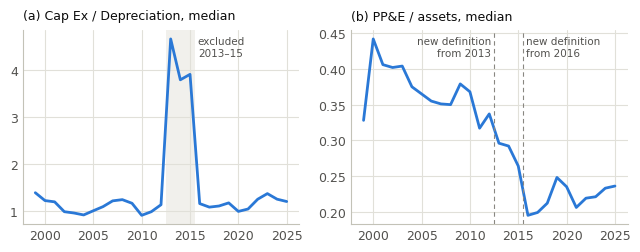

,payout,lev,lev_unadj,lev_book,debt_ebitda,roe,tax,capex_deprec,ppe_assets,capex_assets,div_to_fcfe,div_yield
year,,,,,,,,,,,,
1999,0.247,0.162,0.179,0.456,1.509,0.134,0.376,1.385,0.328,0.103,0.516,0.010
2000,0.182,0.206,0.206,0.460,2.217,0.143,0.259,1.218,0.442,0.089,0.462,0.011
2001,0.122,0.213,0.211,0.442,1.474,0.123,0.244,1.191,0.406,0.079,0.148,0.005
2002,0.159,0.241,0.232,0.433,1.641,0.085,0.209,0.982,0.402,0.072,0.182,0.006
2003,0.291,0.195,0.195,0.430,2.296,0.106,0.225,0.954,0.404,0.066,0.258,0.009
2004,0.170,0.156,0.156,0.410,1.518,0.104,0.203,0.913,0.375,0.058,0.212,0.004
2005,0.261,0.161,0.161,0.374,1.872,0.135,0.192,1.002,0.365,0.059,0.267,0.010
2006,0.247,0.153,0.153,0.385,1.759,0.151,0.189,1.089,0.355,0.063,0.304,0.010
2007,0.234,0.149,0.149,0.380,1.777,0.156,0.186,1.212,0.351,0.071,0.148,0.012


In [6]:
# Data-quality tables (outputs/tab_data_check_*.csv) and the tangibility data-check figure. These tables are
# where the breaks and defects documented above were found; they are recomputed on every run.
chk_cols = ["payout", "lev", "lev_unadj", "lev_book", "debt_ebitda", "roe", "tax", "capex_deprec", "ppe_assets", "capex_assets",
            "div_to_fcfe", "div_yield"]
yearly_medians = panel_prewin.groupby("year")[[c for c in chk_cols if c in panel_prewin]].median().round(3)
yearly_medians.to_csv(OUTDIR / "tab_data_check_yearly_medians.csv")
crossfile_agreement.round(3).to_csv(OUTDIR / "tab_data_check_crossfile.csv")
alignment_check.to_csv(OUTDIR / "tab_data_check_alignment.csv", index=False)
debt_ebitda_check.to_csv(OUTDIR / "tab_data_check_debt_ebitda.csv", index=False)
# Stability of the industry ordering: Spearman correlation of PP&E / assets with the previous year. A definition
# change that reorders industries shows up as a dip (2013 and 2016).
_w = panel_prewin.pivot_table(index="industry", columns="year", values="ppe_assets")
ppe_rank_stability = pd.Series({y: _w[y - 1].corr(_w[y], method="spearman") for y in _w.columns[1:]},
                               name="rank_corr_with_previous_year").round(3)
ppe_rank_stability.rename_axis("year").to_csv(OUTDIR / "tab_data_check_ppe_rank_stability.csv")
print("PP&E / assets, rank correlation with the previous year (reshuffles in 2013 and 2016):")
print(ppe_rank_stability.to_frame().T.to_string(), "\n")
print("Share of industries where divfund payout = divfcfe D/NI (±5%):")
print(crossfile_agreement.round(2).to_frame().T.to_string(), "\n")
# divfund's market cap: total over the non-financial industries, and each industry's log deviation from the average
# of its two neighbouring years. A scale break common to all industries shows as a large deviation with a narrow
# spread between the 10th and 90th percentile (2004); a wider spread means the factor differs by industry (2001).
_mc = panel_prewin.pivot_table(index="industry", columns="year", values="mktcap")
_lmc = np.log(_mc)
_dev = {y: (_lmc[y] - (_lmc[y - 1] + _lmc[y + 1]) / 2).dropna() for y in _lmc.columns[1:-1]}
mktcap_check = pd.DataFrame({"total_usd_tn": _mc.sum() / 1e6,
                             "median_log_dev_from_neighbours": pd.Series({y: d.median() for y, d in _dev.items()}),
                             "p10_log_dev": pd.Series({y: d.quantile(.1) for y, d in _dev.items()}),
                             "p90_log_dev": pd.Series({y: d.quantile(.9) for y, d in _dev.items()})}).round(3)
mktcap_check.rename_axis("year").to_csv(OUTDIR / "tab_data_check_mktcap.csv")
print("divfund market cap, non-financial industries ($tn), and industries' log deviation from the average of the "
      "neighbouring years (median, 10th and 90th percentile):")
print(mktcap_check.T.to_string(), "\n")
print("Constructed vs reported Debt/EBITDA (non-financial industries, years where Damodaran reports it):")
print(debt_ebitda_check.to_string(index=False), "\n")

# Figure (thesis appendix): yearly medians of the two tangibility measures, with the break years marked
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.6), sharex=True)
ax = axes[0]
ax.axvspan(min(TANG_BREAK_YEARS) - .5, max(TANG_BREAK_YEARS) + .5, color=T["band"], lw=0, zorder=0)
ax.plot(yearly_medians.index, yearly_medians["capex_deprec"], color=T["s1"])
ax.text(max(TANG_BREAK_YEARS) + .8, .97, f"excluded\n{min(TANG_BREAK_YEARS)}–{str(max(TANG_BREAK_YEARS))[2:]}",
        transform=ax.get_xaxis_transform(), ha="left", va="top", fontsize=7.5, color=T["ink2"])
ax.set_title("(a) Cap Ex / Depreciation, median")
ax = axes[1]
ax.plot(yearly_medians.index, yearly_medians["ppe_assets"], color=T["s1"])
for k, y in enumerate(PPE_DEF_CHANGES):   # first label left of its line, the others to the right
    ax.axvline(y - .5, color=T["muted"], lw=.8, ls=(0, (4, 3)))
    ax.text(y - .8 if k == 0 else y - .2, .97, f"new definition\nfrom {y}", transform=ax.get_xaxis_transform(),
            ha="right" if k == 0 else "left", va="top", fontsize=7.5, color=T["ink2"])
ax.set_title("(b) PP&E / assets, median")
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_data_check_tangibility.png", dpi=FIG_DPI, close=False); plt.show()
yearly_medians

## 3 · FRED macro data & the interest-rate regime  <span style="color:gray">(§4.1, §4.3.3)</span>

In [7]:
# FRED series -> annual averages -> the rate regime, merged into the panel by calendar year (Damodaran's January
# files describe the previous year, and the loader dates them accordingly).
from paylev.macro import FRED_SERIES, load_fred_snapshot, fetch_fred_live, annualise, add_regime

if FRED_SOURCE == "live":
    try:
        wide = fetch_fred_live(); print("FRED: live download OK")
    except Exception as e:
        print("FRED live download failed:", e, "-> using the pinned snapshot")
        wide = load_fred_snapshot(FRED_SNAPSHOT)
else:
    wide = load_fred_snapshot(FRED_SNAPSHOT)
    print(f"FRED: pinned snapshot {FRED_SNAPSHOT} (set FRED_SOURCE='live' to refresh)")
macro = annualise(wide)

macro = add_regime(macro, HIGH_RATE_RULE, FFR_THRESHOLD)
# Keep the Damodaran years only. ffr_change is computed on the full series first, so 1999 keeps its change from
# 1998; this drops the 1998 lead row and any partial current year.
macro = macro[(macro["year"] >= min(years)) & (macro["year"] <= max(years))].reset_index(drop=True)
panel = panel.merge(macro, on="year", how="left")
print("Regime:", HIGH_RATE_RULE, "| high-rate years:",
      sorted(macro.loc[macro.high_rate == 1, "year"].tolist()))
macro.tail(6)

FRED: pinned snapshot data/fred/fred_snapshot.csv (set FRED_SOURCE='live' to refresh)
Regime: threshold | high-rate years: [1999, 2000, 2001, 2005, 2006, 2007, 2023, 2024, 2025]


,year,ffr,t10,cred_spread,gdp_growth,ffr_change,high_rate,high_rate_post2022
21,2020,0.375833,0.894167,1.125833,-2.081378,-1.782500,0,0
22,2021,0.080000,1.442500,0.688333,6.152022,-0.295833,0,0
23,2022,1.683333,2.951667,0.997500,2.524215,1.603333,0,1
24,2023,5.024167,3.957500,1.050833,2.934361,3.340833,1,1
25,2024,5.143333,4.208333,0.709167,2.793187,0.119167,1,1
26,2025,4.212500,4.291667,0.645833,2.106338,-0.930833,1,1


## 4 · Variable definitions  <span style="color:gray">(§4.3)</span>

`payout` (Dividend Payout) · `div_to_fcfe` (Dividends/FCFE) · `div_yield` (dividends ÷ market cap, no earnings in it; its log `ln_div_yield` is used for the ROE and Debt/EBITDA checks in §9) · `lev` (market D/(D+E), `wacc`) ·
alternative leverage (§9d): `lev_unadj` (market D/(D+E) without capitalised leases), `lev_book` (book D/(D+E)),
`debt_ebitda` (D/(D+E) ÷ EBITDA/EV = debt relative to cash flow) · `tangibility` (**PP&E / total assets**,
percentile rank within the year because the definition changes in 2013 and 2016; the capex-based proxies
Cap Ex/Depreciation, Net Cap Ex/Sales and Invested capital/Sales are robustness checks in §10) · industry controls `roe`, `tax`, `size`=log(Market Cap), and in §9 `invest` (capital spending relative to book capital to 2012 and to total assets from 2013, within-year rank: growth and reinvestment) ·
macro controls `gdp_growth`, `cred_spread` · regime `high_rate`, `ffr`, `ffr_change`.

**Note on macro variables.** Anything that varies only over time (the regime dummy, the fed funds rate, GDP growth,
the credit spread) is perfectly collinear with the year fixed effects. In the two-way FE models these enter only
through interactions with industry variables; `fit_panel` prints any regressor the fixed effects absorb. §9 adds an
industry-FE-only specification in which the macro controls and the regime level are estimated directly.

In [8]:
# Size = log market cap (logs, so the 2001/2004 market-cap inflation is a level shift the year effects absorb),
# and the list of variables the descriptive tables report.
panel["size"] = np.log(panel["mktcap"].where(panel["mktcap"] > 0))
ANALYSIS_VARS = ["payout", "lev", "lev_unadj", "lev_book", "debt_ebitda", "roe", "tax", "size", "tangibility",
                 "gdp_growth", "cred_spread", "high_rate", "ffr", "ffr_change"]
print("Non-null counts:")
print(panel[[c for c in ANALYSIS_VARS if c in panel]].notna().sum().to_string())

Non-null counts:
payout         1921
lev            2102
lev_unadj      2116
lev_book       2099
debt_ebitda    2087
roe            2087
tax            2102
size           2116
tangibility    2116
gdp_growth     2116
cred_spread    2116
high_rate      2116
ffr            2116
ffr_change     2116


## 5 · Descriptive statistics  <span style="color:gray">(§4.4, §6.1)</span>

In [9]:
# Descriptive statistics (thesis §4.4): on the whole panel, and on the estimation sample of the main models (the
# industry-years with payout, leverage and every control present), which is what the regressions use.
desc = panel[[c for c in ANALYSIS_VARS if c in panel]].describe().T
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)
desc.to_csv(OUTDIR / "tab_descriptives.csv")
_est = panel.dropna(subset=["payout", "lev", "roe", "tax", "size"])
desc_est = _est[[c for c in ANALYSIS_VARS if c in _est]].describe().T
desc_est = desc_est[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)
desc_est.to_csv(OUTDIR / "tab_descriptives_estimation_sample.csv")
print(f"Estimation sample of the main models: {len(_est)} industry-years, {_est['industry'].nunique()} industries")

# Overall / between / within standard deviation (Stata's xtsum). The fixed-effects estimates use only the within
# variation (each industry around its own average), which is much smaller than the raw spread suggests.
from paylev.sample import xtsum

sd_decomp = xtsum(panel, ["payout", "lev", "roe", "tax", "size", "tangibility", "div_to_fcfe"])
sd_decomp.round(4).to_csv(OUTDIR / "tab_sd_decomposition.csv")
print("Overall / between / within SD:"); print(sd_decomp.round(3).to_string()); print()
desc

Estimation sample of the main models: 1879 industry-years, 138 industries
Overall / between / within SD:
             sd_overall  sd_between  sd_within
payout            0.375       0.240      0.309
lev               0.139       0.129      0.076
roe               0.123       0.078      0.099
tax               0.095       0.078      0.069
size              1.334       1.340      0.589
tangibility       0.289       0.285      0.093
div_to_fcfe       1.560       0.883      1.398



,count,mean,std,min,25%,50%,75%,max
payout,1921.0,0.369,0.375,0.000,0.158,0.281,0.452,2.578
lev,2102.0,0.238,0.139,0.022,0.135,0.211,0.322,0.638
lev_unadj,2116.0,0.230,0.135,0.022,0.131,0.201,0.310,0.634
lev_book,2099.0,0.448,0.161,0.109,0.335,0.448,0.560,0.849
debt_ebitda,2087.0,2.519,1.496,0.434,1.487,2.256,3.134,8.966
roe,2087.0,0.136,0.123,-0.310,0.079,0.135,0.193,0.508
tax,2102.0,0.155,0.095,0.006,0.081,0.140,0.217,0.421
size,2116.0,11.838,1.334,7.461,10.939,11.893,12.803,15.877
tangibility,2116.0,0.506,0.289,0.013,0.256,0.506,0.756,1.000
gdp_growth,2116.0,2.304,1.730,-2.576,1.819,2.524,2.946,6.152


In [10]:
# Pairwise correlations of the main variables (the heatmap in §11 draws the same matrix)
corr_vars = [c for c in ["payout", "lev", "roe", "tax", "size", "tangibility",
                         "gdp_growth", "cred_spread", "ffr"] if c in panel and panel[c].notna().any()]
panel[corr_vars].corr().round(2)

,payout,lev,roe,tax,size,tangibility,gdp_growth,cred_spread,ffr
payout,1.00,0.17,-0.25,-0.23,0.04,0.14,0.01,-0.06,-0.06
lev,0.17,1.00,-0.17,-0.01,-0.37,0.33,-0.08,0.08,-0.09
roe,-0.25,-0.17,1.00,0.14,0.25,0.02,0.08,-0.05,0.01
tax,-0.23,-0.01,0.14,1.00,-0.16,0.09,0.08,0.11,0.22
size,0.04,-0.37,0.25,-0.16,1.00,-0.16,0.02,-0.11,-0.01
tangibility,0.14,0.33,0.02,0.09,-0.16,1.00,0.00,-0.00,0.00
gdp_growth,0.01,-0.08,0.08,0.08,0.02,0.00,1.00,-0.68,0.26
cred_spread,-0.06,0.08,-0.05,0.11,-0.11,-0.00,-0.68,1.00,-0.32
ffr,-0.06,-0.09,0.01,0.22,-0.01,0.00,0.26,-0.32,1.00


## 6 · Baseline panel regression  <span style="color:gray">(§5.2, §6.2)</span>

$$\text{payout}_{it}=\beta\,\text{lev}_{it}+\gamma' X_{it}+\alpha_i+\delta_t+\varepsilon_{it}$$

Industry & year fixed effects, SE clustered by industry. Substitution view → **β < 0**. $X$ = industry-level controls (ROE, tax rate, size); year-only macro variables are absorbed by $\delta_t$.

In [11]:
# Baseline model (§6): payout on leverage and controls, industry and year effects, industry-clustered SE.
# fit_panel (paylev/estimation.py) wraps linearmodels' PanelOLS; cov="kernel" gives Driscoll-Kraay SE.
from paylev.estimation import fit_panel
fit_panel = partial(fit_panel, dk_bandwidth=DK_BANDWIDTH)

# Industry-level controls. Macro variables vary only by year, so the year effects absorb them; they enter only the
# industry-FE-only robustness model (§9).
BASE_CONTROLS  = ["roe", "tax", "size"]
MACRO_CONTROLS = [c for c in ["gdp_growth", "cred_spread"] if panel[c].notna().any()]
res_base = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS,
                     title="Baseline: payout ~ leverage + controls (two-way FE)")

=== Baseline: payout ~ leverage + controls (two-way FE) ===
obs=1879  industries=138  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5358     0.2375     2.2559     0.0242      0.0700      1.0017
lev            0.3417     0.1487     2.2987     0.0216      0.0501      0.6333
roe           -1.6817     0.2148    -7.8287     0.0000     -2.1031     -1.2604
tax           -0.5359     0.1523    -3.5180     0.0004     -0.8347     -0.2371
size           0.0089     0.0199     0.4463     0.6554     -0.0302      0.0480
R2 (after removing the fixed effects): 0.201


## 7 · Interaction with the rate regime — H2  <span style="color:gray">(§5.3, §6.3)</span>

$$\text{payout}_{it}=\beta_1\text{lev}_{it}+\beta_2(\text{lev}_{it}\times\text{HighRate}_t)+\gamma' X_{it}+\alpha_i+\delta_t+\varepsilon_{it}$$

ME of leverage: low-rate $=\beta_1$, high-rate $=\beta_1+\beta_2$. **H2 ⇔ $\beta_2<0$** (the payout–leverage
slope is more negative when rates are high). H1, about industries *cutting* payouts when rates rise, is a
statement about changes and is tested in change form in §8b.

In [12]:
# H2 (§7): does the payout-leverage slope differ in high-rate years? beta2 on lev x HighRate; the slope is
# beta1 in low-rate years and beta1 + beta2 in high-rate years (H2 expects beta2 < 0).
from paylev.estimation import lincom   # linear combination of coefficients: (estimate, SE, t)

panel["lev_x_high"] = panel["lev"] * panel["high_rate"]
res_int = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                    title="H2: payout ~ lev + lev x HighRate + controls (two-way FE)")
if res_int is not None and "lev_x_high" in getattr(res_int, "params", {}):
    lo = lincom(res_int, {"lev": 1}); hi = lincom(res_int, {"lev": 1, "lev_x_high": 1})
    print("\nMarginal effect of leverage on payout:")
    print(f"  low-rate  (b1)    = {lo[0]:+.4f} (SE {lo[1]:.4f}, t {lo[2]:+.2f})")
    print(f"  high-rate (b1+b2) = {hi[0]:+.4f} (SE {hi[1]:.4f}, t {hi[2]:+.2f})")
    print(f"  interaction b2    = {res_int.params['lev_x_high']:+.4f}  <-- H2 (expect < 0)")

=== H2: payout ~ lev + lev x HighRate + controls (two-way FE) ===
obs=1879  industries=138  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5404     0.2360     2.2900     0.0221      0.0776      1.0033
lev            0.3780     0.1568     2.4111     0.0160      0.0705      0.6854
lev_x_high    -0.0951     0.1532    -0.6206     0.5349     -0.3956      0.2054
roe           -1.6801     0.2145    -7.8338     0.0000     -2.1007     -1.2595
tax           -0.5402     0.1552    -3.4795     0.0005     -0.8447     -0.2357
size           0.0084     0.0197     0.4268     0.6695     -0.0302      0.0470
R2 (after removing the fixed effects): 0.201

Marginal effect of leverage on payout:
  low-rate  (b1)    = +0.3780 (SE 0.1568, t +2.41)
  high-rate (b1+b2) = +0.2829 (SE 0.1803, t +1.57)
 

=== Continuous regime: payout ~ lev + lev x FFR + controls (two-way FE) ===
obs=1879  industries=138  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5421     0.2356     2.3009     0.0215      0.0800      1.0042
lev            0.4041     0.1658     2.4364     0.0149      0.0788      0.7294
lev_x_ffr     -0.0250     0.0361    -0.6909     0.4897     -0.0958      0.0459
roe           -1.6792     0.2143    -7.8361     0.0000     -2.0995     -1.2589
tax           -0.5393     0.1545    -3.4905     0.0005     -0.8423     -0.2362
size           0.0082     0.0196     0.4159     0.6776     -0.0303      0.0467
R2 (after removing the fixed effects): 0.201


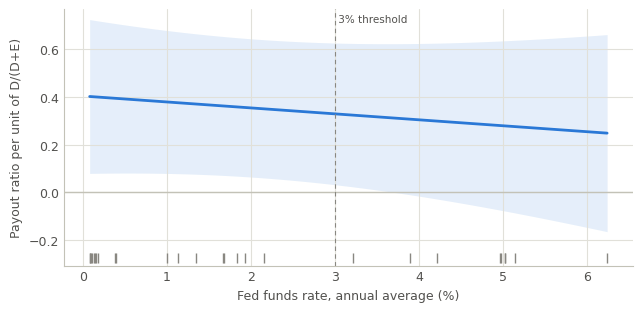

In [13]:
# H2 with the continuous fed funds rate instead of the dummy, and the marginal effect of leverage across the
# observed range of rates (thesis figure).
panel["lev_x_ffr"] = panel["lev"] * panel["ffr"]
res_cont = fit_panel(panel, "payout", ["lev", "lev_x_ffr"] + BASE_CONTROLS,
                     title="Continuous regime: payout ~ lev + lev x FFR + controls (two-way FE)")
if res_cont is not None and "lev_x_ffr" in getattr(res_cont, "params", {}):
    rr = np.linspace(panel["ffr"].min(), panel["ffr"].max(), 50)
    pts = [lincom(res_cont, {"lev": 1, "lev_x_ffr": r}) for r in rr]          # slope at each rate, with its SE
    me = np.array([p[0] for p in pts]); se = np.array([p[1] for p in pts])
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    ax.fill_between(rr, me - 1.96 * se, me + 1.96 * se, color=T["s1"], alpha=.12, lw=0)
    ax.plot(rr, me, color=T["s1"])
    ax.axhline(0, color=T["base"], lw=1)
    ax.axvline(FFR_THRESHOLD, color=T["muted"], lw=.8, ls=(0, (4, 3)))
    ax.text(FFR_THRESHOLD, .98, f" {FFR_THRESHOLD:g}% threshold", transform=ax.get_xaxis_transform(), fontsize=7.5,
            color=T["ink2"], va="top")
    ylo, yhi = ax.get_ylim(); ticks = [v for v in ax.get_yticks() if ylo <= v <= yhi]
    ax.set_ylim(ylo - .1 * (yhi - ylo), yhi); ax.set_yticks(ticks)     # room for the rug under the band
    ax.plot(macro["ffr"], np.full(len(macro), .03), "|", color=T["muted"], ms=7, mew=1,
            transform=ax.get_xaxis_transform())                          # the rates observed, one tick per year
    ax.set_xlabel("Fed funds rate, annual average (%)")
    ax.set_ylabel("Payout ratio per unit of D/(D+E)")
    fig.tight_layout(); save_fig(fig, OUTDIR / "fig_marginal_effect.png", dpi=FIG_DPI, close=False); plt.show()


## 8 · Asset tangibility as a moderator — H3  <span style="color:gray">(§6.4)</span>

In [14]:
# H3 (§8): does tangibility change the regime effect? The triple interaction lev x HighRate x tangibility, with
# every lower-order term; HighRate alone is absorbed by the year effects. H3 expects a positive triple term (a
# smaller regime effect for tangible industries).
if panel["tangibility"].notna().any():
    panel["lev_x_tang"] = panel["lev"] * panel["tangibility"]
    panel["high_x_tang"] = panel["high_rate"] * panel["tangibility"]
    panel["lev_x_high_x_tang"] = panel["lev"] * panel["high_rate"] * panel["tangibility"]
    H3_REGS = ["lev", "tangibility", "lev_x_high", "lev_x_tang", "high_x_tang", "lev_x_high_x_tang"]
    res_h3 = fit_panel(panel, "payout", H3_REGS + BASE_CONTROLS,
        title="H3: triple interaction lev x HighRate x tangibility (two-way FE)")

    # Variant: tangibility as a structural trait, the industry's average within-year rank. Its main effect is
    # absorbed by the industry effects; the interactions are still identified.
    panel["tang_ind"] = panel.groupby("industry")["tangibility"].transform("mean")
    panel["lev_x_tangI"] = panel["lev"] * panel["tang_ind"]
    panel["high_x_tangI"] = panel["high_rate"] * panel["tang_ind"]
    panel["lev_x_high_x_tangI"] = panel["lev"] * panel["high_rate"] * panel["tang_ind"]
    H3I_REGS = ["lev", "tang_ind", "lev_x_high", "lev_x_tangI", "high_x_tangI", "lev_x_high_x_tangI"]
    res_h3_ti = fit_panel(panel, "payout", H3I_REGS + BASE_CONTROLS,
        title="H3 variant: time-invariant industry tangibility (two-way FE)")

    # Descriptive split: the H2 model in the lowest and highest tangibility tercile
    panel["tang_grp"] = pd.qcut(panel["tangibility"], 3, labels=["low", "mid", "high"], duplicates="drop")
    print("\n--- lev x HighRate by tangibility tercile ---")
    for g in ["low", "high"]:
        sub = panel[panel.tang_grp == g]
        if sub["year"].nunique() >= 3:
            fit_panel(sub, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, title=f"Tangibility = {g}")
else:
    print("H3 inactive: no tangibility.")

=== H3: triple interaction lev x HighRate x tangibility (two-way FE) ===
obs=1879  industries=138  years=27


                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.4949     0.2276     2.1746     0.0298      0.0485      0.9412
lev                   0.4401     0.2515     1.7499     0.0803     -0.0532      0.9333
tangibility           0.1608     0.1481     1.0863     0.2775     -0.1296      0.4513
lev_x_high            0.5754     0.2705     2.1268     0.0336      0.0448      1.1060
lev_x_tang           -0.1841     0.5316    -0.3463     0.7292     -1.2267      0.8585
high_x_tang           0.1810     0.1171     1.5452     0.1225     -0.0488      0.4108
lev_x_high_x_tang    -1.1830     0.5476    -2.1603     0.0309     -2.2570     -0.1090
roe                  -1.6949     0.2138    -7.9287     0.0000     -2.1141     -1.2756
tax                  -0.5493     0.1543    -3.5604    

                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  0.5506     0.2254     2.4431     0.0147      0.1086      0.9926
lev                    0.6894     0.3351     2.0569     0.0398      0.0320      1.3467
lev_x_high             0.5833     0.2834     2.0585     0.0397      0.0275      1.1391
lev_x_tangI           -0.6146     0.6683    -0.9197     0.3579     -1.9254      0.6962
high_x_tangI           0.1464     0.1245     1.1763     0.2396     -0.0977      0.3905
lev_x_high_x_tangI    -1.1703     0.5769    -2.0287     0.0426     -2.3018     -0.0389
roe                   -1.6803     0.2133    -7.8783     0.0000     -2.0986     -1.2619
tax                   -0.5514     0.1529    -3.6069     0.0003     -0.8512     -0.2515
size                   0.0061     0.0184   


## 8b · Dividend smoothing: Lintner partial adjustment and H1 in change form  <span style="color:gray">(§6.4, §7.1)</span>

**Lintner (1956).** Firms move dividends only part of the way toward a target share of earnings each year:
$\Delta D_{it} = \text{SOA}\,(r\,E_{it} - D_{i,t-1})$. Scaling by last year's market cap (so large and small
industries are comparable) gives

$$\frac{\Delta D_{it}}{MC_{i,t-1}}=\beta_E\,\frac{E_{it}}{MC_{i,t-1}}+\beta_D\,\frac{D_{i,t-1}}{MC_{i,t-1}}+\alpha_i+\delta_t+\varepsilon_{it},
\qquad \text{SOA}=-\beta_D,\quad r=\beta_E/\text{SOA}.$$

A low speed of adjustment (SOA) means sticky dividends, the proposed explanation for the null in §7.

**H1 as stated is about changes** ("industries with higher leverage *reduce* dividends more during rate-hiking
cycles"). Adding last year's leverage and its interaction with the regime to the change equation tests it directly:
H1 ⇔ $\text{lev}_{t-1}\times\text{Regime}<0$. Three regime definitions: the high-rate dummy, hiking years
(fed funds up ≥ 25bp), and the continuous change in the fed funds rate.

**Estimation notes.** With a lagged dependent variable, industry fixed effects bias the persistence coefficient
downward (Nickell, 1981), so the within estimator *overstates* SOA, while pooled OLS without industry effects
*understates* it; the true value lies between the two (Bond, 2002). Dollar dividends and net income come from
`divfcfe`; in the years flagged by the §2 cross-file check (2000, 2007) neither is used, also not as last year's
value; industries merged by the rename map are summed. The scaling by last year's market cap divides the
variables of 2002 and 2005 by an inflated market cap (the 2001 and 2004 figures, §2); the factor is roughly common
to all industries, which the year effects partly absorb, so the key models are also reported without those years. Lags require the previous calendar year (no gap bridging), and 2013 is dropped from these models because
the 2012→2013 change crosses Damodaran's reclassification: the typical industry's dividends change by
39% that year (median absolute change) versus 14% in other years, which reflects firms moving
between industries rather than dividend decisions.


In [15]:
# Lintner models and H1 in change form (§8b), on a frame of dollar figures.

# ---- Dollar frame ($m): dividends and net income from divfcfe, market cap from divfund. Industries merged by the
#      rename map are summed. divfcfe's 2000 and 2007 figures (§2) are not used, not even as last year's value.
usd = raw[["industry", "year", "div_usd", "ni_usd", "mktcap"]].copy()
usd["industry"] = usd["industry"].replace(INDUSTRY_RENAME)
usd = (usd[usd["industry"].isin(panel["industry"])]
       .groupby(["industry", "year"], as_index=False)[["div_usd", "ni_usd", "mktcap"]].sum(min_count=1))
usd.loc[usd["year"].isin(DIVFCFE_BAD_YEARS), ["div_usd", "ni_usd"]] = np.nan
L = usd.merge(panel[["industry", "year", "payout", "lev", "roe", "tax", "size",
                     "high_rate", "ffr_change", "in_core"]], on=["industry", "year"], how="inner")

# ---- One-year lags that never bridge a gap: merge on year + 1, so an industry missing year t-1 gets no lag.
#      Everything is scaled by last year's market cap, so large and small industries are comparable.
_lag = L[["industry", "year", "div_usd", "mktcap", "lev", "payout"]].copy(); _lag["year"] += 1
L = L.merge(_lag.rename(columns={c: c + "_l1" for c in ["div_usd", "mktcap", "lev", "payout"]}),
            on=["industry", "year"], how="left")
L["dD"] = (L["div_usd"] - L["div_usd_l1"]) / L["mktcap_l1"]      # change in dividends
L["E"]  = L["ni_usd"] / L["mktcap_l1"]                            # current earnings
L["Dl"] = L["div_usd_l1"] / L["mktcap_l1"]                        # last year's dividends
L.loc[L["year"] == RECLASS_YEAR, ["dD", "payout_l1", "lev_l1"]] = np.nan   # 2012 -> 2013 crosses the reclassification
L = winsorize(L, ["dD", "E", "Dl"])
L["hike"] = (L["ffr_change"] >= HIKE_THRESHOLD).astype(int)     # hiking year: the annual average rose >= 25bp
for a, b in [("E", "high_rate"), ("Dl", "high_rate"), ("lev_l1", "high_rate"),
             ("lev_l1", "hike"), ("lev_l1", "ffr_change")]:
    L[f"{a}_x_{b}"] = L[a] * L[b]
print("Hiking years (fed funds up >= %.2fpp):" % HIKE_THRESHOLD,
      sorted(int(y) for y in L.loc[L["hike"] == 1, "year"].unique()))
# why 2013 is dropped: dividends change far more across the reclassification than in any other year
_chg = (L["div_usd"] / L["div_usd_l1"] - 1).abs()
print(f"Median absolute change in industry dividends: {_chg[L['year'] == RECLASS_YEAR].median():.0%} in "
      f"{RECLASS_YEAR} (reclassification) vs {_chg[L['year'] != RECLASS_YEAR].median():.0%} in other years\n")

# ---- Models. L1: Lintner, SOA = -coefficient on Dl (within FE overstates it, pooled understates it, Nickell
#      bias; the truth lies between). L2: does smoothing differ by regime? L3: H1, lev(t-1) x regime in the change
#      equation (H1 expects < 0), with three regime definitions; the hiking-year one is the H1 test. R: persistence
#      of the payout ratio itself.
lint = {}
lint["L1_within"] = fit_panel(L, "dD", ["E", "Dl"], title="L1 Lintner, two-way FE (SOA upper bound)")
lint["L1_pooled"] = fit_panel(L, "dD", ["E", "Dl"], entity=False,
                              title="L1 Lintner, year FE only (SOA lower bound)")
lint["L2_regime"] = fit_panel(L, "dD", ["E", "Dl", "E_x_high_rate", "Dl_x_high_rate"],
                              title="L2 Smoothing by regime")
H1C = ["E", "Dl", "lev_l1"]
lint["L3_high"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_high_rate"], title="L3 H1 in change form: high-rate years")
lint["L3_hike"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_hike"], title="L3 H1 in change form: hiking years")
lint["L3_dffr"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_ffr_change"], title="L3 H1 in change form: change in FFR")
lint["L3_core"]  = fit_panel(L[L["in_core"]], "dD", H1C + ["lev_l1_x_high_rate"],
                             title="L3 H1 in change form: high-rate years, stable core")
# the same without 2002 and 2005, whose variables are scaled by the inflated 2001 and 2004 market caps (§2)
_after_mc = L["year"].isin([y + 1 for y in MKTCAP_BREAK_YEARS])
lint["L1_within_mc"] = fit_panel(L[~_after_mc], "dD", ["E", "Dl"],
                                 title="L1 Lintner, two-way FE, without the years scaled by the 2001/2004 market caps")
lint["L3_hike_mc"] = fit_panel(L[~_after_mc], "dD", H1C + ["lev_l1_x_hike"],
                               title="L3 H1 in change form: hiking years, without the years scaled by the 2001/2004 market caps")
lint["R_within"] = fit_panel(L, "payout", ["payout_l1"] + BASE_CONTROLS, title="Payout-ratio persistence, two-way FE")
lint["R_pooled"] = fit_panel(L, "payout", ["payout_l1"] + BASE_CONTROLS, entity=False,
                             title="Payout-ratio persistence, year FE only")

# ---- Summary and table (outputs/tab_lintner.csv)
soa_hi, soa_lo = -lint["L1_within"].params["Dl"], -lint["L1_pooled"].params["Dl"]
target = lint["L1_pooled"].params["E"] / soa_lo
rho_lo, rho_hi = lint["R_within"].params["payout_l1"], lint["R_pooled"].params["payout_l1"]
print(f"\nSpeed of adjustment of dividends: between {soa_lo:.2f} and {soa_hi:.2f} per year "
      f"(dividend persistence {1 - soa_hi:.2f}-{1 - soa_lo:.2f}); target payout (pooled) = {target:.2f}")
print(f"Persistence of the payout RATIO: {rho_lo:.2f}-{rho_hi:.2f}")

KEYS = [("L1_within", "Dl", "Lintner, two-way FE"), ("L1_pooled", "Dl", "Lintner, year FE only"),
        ("L2_regime", "Dl_x_high_rate", "Smoothing x high-rate"), ("L2_regime", "E_x_high_rate", "Earnings x high-rate"),
        ("L3_high", "lev_l1_x_high_rate", "H1 change form: high-rate"),
        ("L3_hike", "lev_l1_x_hike", "H1 change form: hiking year"),
        ("L3_dffr", "lev_l1_x_ffr_change", "H1 change form: change in FFR"),
        ("L3_core", "lev_l1_x_high_rate", "H1 change form: high-rate, stable core"),
        ("L1_within_mc", "Dl", "Lintner, two-way FE, excl. 2002 and 2005"),
        ("L3_hike_mc", "lev_l1_x_hike", "H1 change form: hiking year, excl. 2002 and 2005"),
        ("R_within", "payout_l1", "Payout-ratio persistence, two-way FE"),
        ("R_pooled", "payout_l1", "Payout-ratio persistence, year FE only")]
lint_tbl = pd.DataFrame([{"model": lab, "term": t, "coef": lint[k].params[t], "se": lint[k].std_errors[t],
                          "p": lint[k].pvalues[t], "N": int(lint[k].nobs)} for k, t, lab in KEYS]).round(6)
lint_tbl.to_csv(OUTDIR / "tab_lintner.csv", index=False)
lint_tbl


Hiking years (fed funds up >= 0.25pp): [2000, 2005, 2006, 2016, 2017, 2018, 2019, 2022, 2023]
Median absolute change in industry dividends: 39% in 2013 (reclassification) vs 14% in other years

=== L1 Lintner, two-way FE (SOA upper bound) ===
obs=1623  industries=128  years=21
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0053     0.0005     9.9029     0.0000      0.0042      0.0063
E              0.0215     0.0071     3.0492     0.0023      0.0077      0.0353
Dl            -0.3600     0.0294    -12.239     0.0000     -0.4177     -0.3023
R2 (after removing the fixed effects): 0.193
=== L1 Lintner, year FE only (SOA lower bound) ===
obs=1623  industries=128  years=21
                             Parameter Estimates                              
            Parameter  Std. Err.     T

                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  0.0038     0.0007     5.1716     0.0000      0.0024      0.0053
E                      0.0240     0.0069     3.4771     0.0005      0.0104      0.0375
Dl                    -0.3834     0.0306    -12.524     0.0000     -0.4435     -0.3234
lev_l1                 0.0065     0.0032     2.0536     0.0402      0.0003      0.0127
lev_l1_x_high_rate     0.0012     0.0040     0.2982     0.7656     -0.0066      0.0090
R2 (after removing the fixed effects): 0.199
=== L3 H1 in change form: hiking years ===
obs=1623  industries=128  years=21
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------

=== L1 Lintner, two-way FE, without the years scaled by the 2001/2004 market caps ===
obs=1463  industries=128  years=19
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0059     0.0006     9.5981     0.0000      0.0047      0.0071
E              0.0233     0.0077     3.0172     0.0026      0.0081      0.0384
Dl            -0.3823     0.0305    -12.517     0.0000     -0.4422     -0.3224
R2 (after removing the fixed effects): 0.211
=== L3 H1 in change form: hiking years, without the years scaled by the 2001/2004 market caps ===
obs=1463  industries=128  years=19
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.2967     0.1232     2.4086     0.0161      0.0551      0.5382
payout_l1      0.4659     0.0663     7.0290     0.0000      0.3359      0.5959
roe           -0.9980     0.1907    -5.2339     0.0000     -1.3720     -0.6240
tax           -0.1181     0.1440    -0.8200     0.4123     -0.4006      0.1644
size           0.0067     0.0091     0.7305     0.4652     -0.0112      0.0245
R2 (after removing the fixed effects): 0.296

Speed of adjustment of dividends: between 0.09 and 0.36 per year (dividend persistence 0.64-0.91); target payout (pooled) = 0.29
Persistence of the payout RATIO: 0.18-0.47


,model,term,coef,se,p,N
0,"Lintner, two-way FE",Dl,-0.360017,0.029417,0.000000,1623
1,"Lintner, year FE only",Dl,-0.085259,0.026946,0.001585,1623
2,Smoothing x high-rate,Dl_x_high_rate,0.030433,0.039326,0.439134,1623
3,Earnings x high-rate,E_x_high_rate,-0.003169,0.013117,0.809146,1623
4,H1 change form: high-rate,lev_l1_x_high_rate,0.001183,0.003968,0.765627,1623
5,H1 change form: hiking year,lev_l1_x_hike,0.001455,0.002305,0.527973,1623
6,H1 change form: change in FFR,lev_l1_x_ffr_change,0.000758,0.001065,0.476943,1623
7,"H1 change form: high-rate, stable core",lev_l1_x_high_rate,0.003103,0.002902,0.285200,941
8,"Lintner, two-way FE, excl. 2002 and 2005",Dl,-0.382300,0.030544,0.000000,1463
9,"H1 change form: hiking year, excl. 2002 and 2005",lev_l1_x_hike,0.001501,0.002640,0.569745,1463


## 9 · Robustness  <span style="color:gray">(§5.5, §6.5)</span>

Alt payout measures · **stable-core sample** (a check on the 2013 reclassification) · **2022–25 regime dummy** · two-way clustering · ex-COVID · **ex-financial crisis (2008–09)** · **growth / reinvestment control** · lagged leverage · **industry FE only with macro controls** ·
**ROE mechanical-link check (log dividend yield as an earnings-free DV)** · **backward elimination of insignificant controls** · **H3 in the stable core** · **payout as reported (incl. non-positive earnings)** · **Driscoll–Kraay SE** · **first differences** ·
**weighting by number of firms** (the last three also stress-test the leverage coefficient, §9c) ·
**alternative leverage measures**: without leases, book, Debt/EBITDA (§9d) · **H3 sensitivity** (inference,
sample, continuous rate).

In [16]:
# Robustness (§9). Each entry of `robust` is the H2 model re-estimated one way; the summary table in the next cell
# reports the regime-interaction term of every one. `stress_base` holds the matching baseline models for the stress
# test of the leverage coefficient (§9c); (p) collects the sensitivity of the H3 triple term.
robust = {}
# (a) stable core: industries present in at least MIN_YEARS_CORE years (a check on the 2013 reclassification)
print(">>> Stable core (industries present >= MIN_YEARS_CORE years)")
robust["core"] = fit_panel(panel[panel.in_core], "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                           title=f"Stable core ({len(CORE)} industries)")
# (b) the latest tightening cycle as the regime: a dummy for 2022-2025
pp = panel.copy(); pp["lev_x_high"] = pp["lev"] * pp["high_rate_post2022"]
print("\n>>> Regime = 2022-2025 dummy")
robust["post2022"] = fit_panel(pp, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                               title="Regime = 2022-2025 dummy")
# (c) other payout measures. The dividend yield is not one of them: yield and D/(D+E) both contain market equity,
#     so its leverage terms are partly mechanical; it serves the ROE check in (h) and is reported with a caveat.
for dv_alt in ["div_to_fcfe", "totpayout_ni"]:
    if dv_alt in panel and panel[dv_alt].notna().any():
        print(f"\n>>> Alt payout: {dv_alt}")
        robust[dv_alt] = fit_panel(panel, dv_alt, ["lev", "lev_x_high"] + BASE_CONTROLS, title=f"DV={dv_alt}")
# (d) two-way clustering (industry and year)
print("\n>>> Two-way clustered SE")
robust["twoway"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                             cluster_time=True, title="Two-way clustering")
# (e) without the COVID years
print("\n>>> Excluding COVID years", COVID_YEARS)
robust["noCovid"] = fit_panel(panel[~panel.year.isin(COVID_YEARS)], "payout",
                              ["lev", "lev_x_high"] + BASE_CONTROLS, title="Excl. COVID")
# (e2) without the financial crisis
print("\n>>> Excluding the financial-crisis years", GFC_YEARS)
robust["noGFC"] = fit_panel(panel[~panel.year.isin(GFC_YEARS)], "payout",
                            ["lev", "lev_x_high"] + BASE_CONTROLS, title="Excl. financial crisis")
# (e3) capital spending as a control (growth / reinvestment): industries that invest heavily may both borrow more
#      and pay out less
print("\n>>> Growth / reinvestment control (capital spending, within-year rank)")
robust["growth"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS + ["invest"],
                             title="Interaction + capital spending intensity")
# (f) lagged leverage: previous calendar year only (merged on year + 1, so no gap is bridged); 2013 dropped, as its
#     lag comes from before the reclassification
pl = panel.merge(panel[["industry", "year", "lev"]].assign(year=lambda d: d["year"] + 1)
                 .rename(columns={"lev": "lev_lag"}), on=["industry", "year"], how="left")
pl.loc[pl["year"] == RECLASS_YEAR, "lev_lag"] = np.nan
pl["lev_lag_x_high"] = pl["lev_lag"] * pl["high_rate"]
if pl["lev_lag"].notna().any():
    print("\n>>> Lagged leverage")
    robust["lagged"] = fit_panel(pl, "payout", ["lev_lag", "lev_lag_x_high"] + BASE_CONTROLS,
                                 title="Lagged leverage")

# (g) industry effects only: without year effects the macro controls and the regime level are estimable; errors
#     are clustered by industry and year, since the macro variables are common to all industries in a year
print("\n>>> Industry FE only, with macro controls and the regime level")
robust["indFE_macro"] = fit_panel(panel, "payout",
    ["lev", "high_rate", "lev_x_high"] + BASE_CONTROLS + MACRO_CONTROLS,
    time=False, cluster_time=True, title="Industry FE + macro controls (no year FE), two-way clustered")

# (h) Is the ROE coefficient mechanical? The payout ratio is D/NI and ROE is NI/E, so both contain net income, and
#     Dividends/FCFE does not solve this (FCFE = NI - net capex - change in working capital + net borrowing). The
#     dividend yield (D / market cap, in logs, §2) contains no earnings, so its ROE coefficient is free of the
#     accounting link. The yield's leverage terms are partly mechanical (market equity in both); the check is
#     about ROE only. "Without ROE" uses the main model's observations, so only the specification changes.
print("\n>>> ROE mechanical-link check: interaction model without ROE")
robust["noROE"] = fit_panel(panel[panel["roe"].notna()], "payout", ["lev", "lev_x_high", "tax", "size"],
                            title="Interaction without ROE (main-model sample)")
roe_yield = fit_panel(panel, "ln_div_yield", ["lev", "lev_x_high"] + BASE_CONTROLS,
                      title="DV = log dividend yield (ROE check)")
robust["ln_div_yield"] = roe_yield   # reported in the summary with its caveat, not among the payout specifications
_roe_rows = []
for dv_, res_, ni_in in [("payout (D/NI)", res_int, "yes"), ("Dividends/FCFE", robust.get("div_to_fcfe"), "yes (via FCFE)"),
                         ("log dividend yield (D/MC)", roe_yield, "no")]:
    if res_ is not None and "roe" in res_.params:
        _roe_rows.append({"dependent variable": dv_, "net income in DV": ni_in, "roe_coef": res_.params["roe"],
                          "se": res_.std_errors["roe"], "p": res_.pvalues["roe"], "N": int(res_.nobs)})
roe_check = pd.DataFrame(_roe_rows).round(6)
roe_check.to_csv(OUTDIR / "tab_roe_check.csv", index=False)
print("\nROE coefficient by dependent variable (interaction model, two-way FE):")
print(roe_check.to_string(index=False))

# (i) backward elimination (a posteriori): drop the least significant control while its p > 0.05, refitting each
#     time; the hypothesis terms (lev, lev_x_high) are never dropped
print("\n>>> Backward elimination of insignificant controls (a posteriori, 5%)")
keep = list(BASE_CONTROLS)
while True:
    r_ = fit_panel(panel, "payout", ["lev", "lev_x_high"] + keep, title=f"Elimination step: controls={keep}")
    if not keep or r_.pvalues[keep].max() <= 0.05:
        break
    pv = r_.pvalues[keep]
    print(f"   -> dropping {pv.idxmax()} (p={pv.max():.3f})\n")
    keep.remove(pv.idxmax())
robust["elimination"] = r_
print("Controls retained by elimination:", keep)

# (j) H3 in the stable core
if "res_h3" in globals():
    print("\n>>> H3 in the stable core")
    robust["H3_core"] = fit_panel(panel[panel.in_core], "payout", H3_REGS + BASE_CONTROLS,
                                  title="H3: stable core")

# (k) the payout as Damodaran reports it, including industry-years with non-positive earnings
print("\n>>> Payout as reported, including industry-years with net income <= 0")
robust["payout_all"] = fit_panel(panel, "payout_all", ["lev", "lev_x_high"] + BASE_CONTROLS,
                                 title="DV = payout as reported (incl. net income <= 0)")

# (k2) without the row-level cross-file check (keeps the payouts that contradict divfcfe's D/NI)
if "payout_rowcheck_off" in panel:
    print("\n>>> Payout without the row-level cross-file check")
    robust["rowcheck_off"] = fit_panel(panel, "payout_rowcheck_off", ["lev", "lev_x_high"] + BASE_CONTROLS,
                                       title="DV = payout, rows contradicting divfcfe kept")

# ---- Stress tests of the leverage coefficient and of H2 (§9c): each pairs a baseline model (leverage
#      coefficient) with an interaction model (beta2) under the same challenge.
stress_base = {"main": res_base}
stress_base["noGFC"] = fit_panel(panel[~panel.year.isin(GFC_YEARS)], "payout", ["lev"] + BASE_CONTROLS,
                                 title="Baseline, excl. financial crisis")
stress_base["growth"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS + ["invest"],
                                  title="Baseline + capital spending intensity")
# (l) Driscoll-Kraay SE: robust to cross-sectional dependence (a common shock hits every industry in a year) and to
#     serial correlation up to DK_BANDWIDTH lags
print("\n>>> Driscoll-Kraay standard errors")
stress_base["dk"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, cov="kernel",
                              title="Baseline, Driscoll-Kraay SE")
robust["dk"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, cov="kernel",
                         title="Interaction, Driscoll-Kraay SE")
stress_base["twoway"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, cluster_time=True,
                                  title="Baseline, two-way clustered SE")

# (m) first differences: remove the industry effects by differencing instead of demeaning. Consecutive years only
#     (a change across a gap is left out), with year effects; 2013 dropped (the change crosses the reclassification)
_s = panel.sort_values(["industry", "year"])
_g = _s.groupby("industry")
_consec = _g["year"].shift(1) == _s["year"] - 1
fd = _s[["industry", "year", "in_core"]].copy()
for v in ["payout", "lev", "lev_x_high"] + BASE_CONTROLS:
    fd["d_" + v] = (_s[v] - _g[v].shift(1)).where(_consec)
fd.loc[fd["year"] == RECLASS_YEAR, [c for c in fd.columns if c.startswith("d_")]] = np.nan
D_CONTROLS = ["d_" + c for c in BASE_CONTROLS]
print("\n>>> First differences (with year effects)")
stress_base["fd"] = fit_panel(fd, "d_payout", ["d_lev"] + D_CONTROLS, entity=False,
                              title="Baseline, first differences")
robust["fd"] = fit_panel(fd, "d_payout", ["d_lev", "d_lev_x_high"] + D_CONTROLS, entity=False,
                         title="Interaction, first differences")

# (n) weighted by the number of firms in the industry (every industry counts equally otherwise)
print("\n>>> Weighted by number of firms")
stress_base["wls"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, weights="n_firms",
                               title="Baseline, weighted by number of firms")
robust["wls"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, weights="n_firms",
                          title="Interaction, weighted by number of firms")

# (o) other leverage measures (§9d): each replaces `lev` in the baseline and the interaction model; m_x_high is the
#     measure times the high-rate dummy. Debt/EBITDA is also interacted with the fed funds rate: with year effects,
#     FFR x Debt/EBITDA is the part of an interest-burden proxy (rate x debt / cash flow) that differs across
#     industries. Debt/EBITDA and the payout ratio both contain earnings, so the log dividend yield (no earnings in
#     it) is a second dependent variable; Debt/EBITDA contains no market equity (D/(D+E) / (EBITDA/EV) = D/EBITDA),
#     so the yield check is valid for it.
ALT_LEV = {"lev": "Market D/(D+E), main (leases from 2013)", "lev_unadj": "Market D/(D+E), without leases",
           "lev_book": "Book D/(D+E)", "debt_ebitda": "Debt / EBITDA"}
alt_base, alt_int = {}, {}
for v, lab in ALT_LEV.items():
    d = panel.assign(m_x_high=panel[v] * panel["high_rate"], m_x_ffr=panel[v] * panel["ffr"])
    print(f"\n>>> Leverage measure: {lab}")
    alt_base[v] = fit_panel(d, "payout", [v] + BASE_CONTROLS, title=f"Baseline, leverage = {lab}")
    alt_int[v] = fit_panel(d, "payout", [v, "m_x_high"] + BASE_CONTROLS, title=f"Interaction, leverage = {lab}")
    if v != "lev":
        robust[v] = alt_int[v]
    if v == "debt_ebitda":
        alt_int["debt_ebitda_ffr"] = fit_panel(d, "payout", [v, "m_x_ffr"] + BASE_CONTROLS,
                                               title="Debt/EBITDA x fed funds rate (interest-burden proxy)")
        alt_base["debt_ebitda_yield"] = fit_panel(d, "ln_div_yield", [v] + BASE_CONTROLS,
                                                  title="DV = log dividend yield, baseline, Debt/EBITDA")
        alt_int["debt_ebitda_yield"] = fit_panel(d, "ln_div_yield", [v, "m_x_high"] + BASE_CONTROLS,
                                                 title="DV = log dividend yield, Debt/EBITDA x high-rate")

# (p) sensitivity of the H3 triple term (primary tangibility measure) to the inference, the sample, capital
#     spending and the regime definition (outputs/tab_H3_robustness.csv)
if "res_h3" in globals():
    H3M = H3_REGS + BASE_CONTROLS
    print("\n>>> H3 sensitivity")
    h3_rob = {"Main (industry-clustered SE)": res_h3,
              "Driscoll-Kraay SE": fit_panel(panel, "payout", H3M, cov="kernel", title="H3, Driscoll-Kraay SE"),
              "Two-way clustered SE": fit_panel(panel, "payout", H3M, cluster_time=True, title="H3, two-way clustered SE"),
              "Excl. 2020-21": fit_panel(panel[~panel.year.isin(COVID_YEARS)], "payout", H3M, title="H3, excl. COVID"),
              "Excl. 2008-09": fit_panel(panel[~panel.year.isin(GFC_YEARS)], "payout", H3M, title="H3, excl. GFC"),
              "Weighted by number of firms": fit_panel(panel, "payout", H3M, weights="n_firms", title="H3, weighted"),
              # capital spending is correlated with PP&E: does the triple term survive holding it fixed, and a
              # horse race in which capital spending gets the same interactions as tangibility?
              "Capital spending control": fit_panel(panel, "payout", H3M + ["invest"],
                                                    title="H3 + capital spending intensity"),
              "Capital spending, all interactions": fit_panel(
                  panel.assign(lev_x_inv=panel.lev * panel.invest, high_x_inv=panel.high_rate * panel.invest,
                               lev_x_high_x_inv=panel.lev * panel.high_rate * panel.invest),
                  "payout", H3M + ["invest", "lev_x_inv", "high_x_inv", "lev_x_high_x_inv"],
                  title="H3 horse race with capital spending (all interactions)"),
              "Stable core": robust.get("H3_core")}
    # the fed funds rate in place of the dummy (same column names, so the triple term is read the same way)
    _c = panel.assign(lev_x_high=panel.lev * panel.ffr, high_x_tang=panel.ffr * panel.tangibility,
                      lev_x_high_x_tang=panel.lev * panel.ffr * panel.tangibility)
    h3_rob["Continuous rate (FFR, per pp)"] = fit_panel(_c, "payout", H3M, title="H3 with the fed funds rate")
    h3_rob_tbl = pd.DataFrame([{"specification": k, "triple_coef": r.params["lev_x_high_x_tang"],
                                "se": r.std_errors["lev_x_high_x_tang"], "p": r.pvalues["lev_x_high_x_tang"],
                                "N": int(r.nobs)} for k, r in h3_rob.items() if r is not None]).round(6)
    h3_rob_tbl.to_csv(OUTDIR / "tab_H3_robustness.csv", index=False)
    print("\nH3 triple term across specifications:"); print(h3_rob_tbl.to_string(index=False))


>>> Stable core (industries present >= MIN_YEARS_CORE years)
=== Stable core (46 industries) ===
obs=1088  industries=46  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5823     0.2753     2.1156     0.0346      0.0422      1.1225
lev            0.4883     0.1531     3.1888     0.0015      0.1878      0.7887
lev_x_high    -0.0908     0.1778    -0.5108     0.6096     -0.4396      0.2580
roe           -1.6140     0.2538    -6.3589     0.0000     -2.1121     -1.1160
tax           -0.4624     0.1969    -2.3486     0.0190     -0.8488     -0.0760
size           0.0040     0.0232     0.1739     0.8620     -0.0415      0.0496
R2 (after removing the fixed effects): 0.195

>>> Regime = 2022-2025 dummy
=== Regime = 2022-2025 dummy ===
obs=1879  industries=138  years=27
               


>>> Alt payout: div_to_fcfe
=== DV=div_to_fcfe ===
obs=1587  industries=133  years=25


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.9047     1.2946     0.6988     0.4848     -1.6348      3.4441
lev            0.8580     0.7381     1.1623     0.2453     -0.5900      2.3059
lev_x_high    -0.2489     0.6484    -0.3839     0.7011     -1.5208      1.0230
roe           -3.8742     0.7429    -5.2146     0.0000     -5.3316     -2.4168
tax           -1.7512     1.6903    -1.0360     0.3004     -5.0670      1.5645
size           0.0447     0.1036     0.4314     0.6663     -0.1585      0.2479
R2 (after removing the fixed effects): 0.052

>>> Alt payout: totpayout_ni
=== DV=totpayout_ni ===
obs=740  industries=91  years=11
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5404     0.2105     2.5675     0.0103      0.1276      0.9533
lev            0.3780     0.1591     2.3762     0.0176      0.0660      0.6899
lev_x_high    -0.0951     0.1489    -0.6385     0.5232     -0.3872      0.1970
roe           -1.6801     0.2218    -7.5751     0.0000     -2.1151     -1.2451
tax           -0.5402     0.1551    -3.4834     0.0005     -0.8443     -0.2360
size           0.0084     0.0171     0.4925     0.6224     -0.0251      0.0419
R2 (after removing the fixed effects): 0.201

>>> Excluding COVID years [2020, 2021]
=== Excl. COVID ===
obs=1758  industries=138  years=25


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5238     0.2387     2.1944     0.0283      0.0556      0.9920
lev            0.3329     0.1518     2.1936     0.0284      0.0352      0.6306
lev_x_high    -0.0931     0.1523    -0.6113     0.5411     -0.3919      0.2057
roe           -1.7274     0.2164    -7.9806     0.0000     -2.1519     -1.3028
tax           -0.5900     0.1580    -3.7349     0.0002     -0.8998     -0.2801
size           0.0115     0.0199     0.5782     0.5632     -0.0275      0.0505
R2 (after removing the fixed effects): 0.202

>>> Excluding the financial-crisis years [2008, 2009]
=== Excl. financial crisis ===
obs=1732  industries=138  years=25
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat 

...

                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const          -2.0855     0.7502    -2.7799     0.0055     -3.5570     -0.6141
debt_ebitda    -0.0530     0.0363    -1.4607     0.1443     -0.1241      0.0182
roe             0.4265     0.2591     1.6460     0.0999     -0.0817      0.9348
tax             0.2604     0.5555     0.4687     0.6394     -0.8292      1.3499
size           -0.2127     0.0631    -3.3725     0.0008     -0.3364     -0.0890
R2 (after removing the fixed effects): 0.047
=== DV = log dividend yield, Debt/EBITDA x high-rate ===
obs=1874  industries=138  years=25
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.4949     0.1562     3.1673     0.0016      0.1884      0.8013
lev                   0.4401     0.1666     2.6418     0.0083      0.1133      0.7668
tangibility           0.1608     0.1336     1.2043     0.2286     -0.1011      0.4228
lev_x_high            0.5754     0.3360     1.7127     0.0869     -0.0835      1.2343
lev_x_tang           -0.1841     0.3985    -0.4619     0.6442     -0.9657      0.5975
high_x_tang           0.1810     0.0659     2.7472     0.0061      0.0518      0.3103
lev_x_high_x_tang    -1.1830     0.3889    -3.0420     0.0024     -1.9457     -0.4202
roe                  -1.6949     0.0901    -18.802     0.0000     -1.8717     -1.5181
tax                  -0.5493     0.1231    -4.4617    

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.4972     0.2373     2.0952     0.0363      0.0317      0.9627
lev                   0.3054     0.2251     1.3570     0.1750     -0.1361      0.7469
tangibility           0.0987     0.1498     0.6590     0.5100     -0.1951      0.3925
lev_x_high            0.6119     0.2682     2.2810     0.0227      0.0857      1.1380
lev_x_tang        -2.613e-05     0.5226 -4.999e-05     1.0000     -1.0252      1.0251
high_x_tang           0.2075     0.1181     1.7561     0.0793     -0.0243      0.4392
lev_x_high_x_tang    -1.2575     0.5448    -2.3084     0.0211     -2.3260     -0.1890
roe                  -1.7308     0.2136    -8.1021     0.0000     -2.1499     -1.3118
tax                  -0.6026     0.1580    -3.8142    

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.7007     0.3091     2.2669     0.0235      0.0945      1.3070
lev                   0.6212     0.2579     2.4086     0.0161      0.1154      1.1271
tangibility           0.1183     0.1733     0.6826     0.4949     -0.2216      0.4583
lev_x_high            0.4024     0.1910     2.1063     0.0353      0.0277      0.7771
lev_x_tang           -0.4482     0.6603    -0.6788     0.4974     -1.7432      0.8468
high_x_tang           0.1680     0.1176     1.4291     0.1532     -0.0626      0.3986
lev_x_high_x_tang    -1.0483     0.4788    -2.1895     0.0287     -1.9875     -0.1092
roe                  -1.9377     0.2375    -8.1592     0.0000     -2.4034     -1.4719
tax                  -0.4895     0.1902    -2.5745    

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.5624     0.2241     2.5095     0.0122      0.1228      1.0019
lev                   0.5282     0.2520     2.0960     0.0362      0.0339      1.0225
tangibility           0.1440     0.1806     0.7975     0.4253     -0.2101      0.4981
lev_x_high            0.3986     0.2691     1.4813     0.1387     -0.1292      0.9264
lev_x_tang            0.1100     0.6308     0.1744     0.8616     -1.1272      1.3471
high_x_tang           0.2782     0.1706     1.6301     0.1033     -0.0565      0.6129
lev_x_high_x_tang    -1.8192     0.7358    -2.4726     0.0135     -3.2624     -0.3761
roe                  -1.6655     0.2157    -7.7201     0.0000     -2.0886     -1.2424
tax                  -0.5392     0.1542    -3.4978    

In [17]:
# Robustness summary (Appendix C): the regime-interaction term of every model in `robust`
# (outputs/tab_robustness_summary.csv). KEY names the term where it is not lev_x_high; LABEL gives the table label.
KEY = {"lagged": "lev_lag_x_high", "H3_core": "lev_x_high_x_tang", "fd": "d_lev_x_high",
       "lev_unadj": "m_x_high", "lev_book": "m_x_high", "debt_ebitda": "m_x_high"}
LABEL = {"core": "Stable core", "post2022": "Regime = 2022-25 dummy", "div_to_fcfe": "DV = Dividends/FCFE",
         "totpayout_ni": "DV = (Div+Buybacks)/NI", "twoway": "Two-way clustered SE", "noCovid": "Excl. 2020-21",
         "noGFC": "Excl. 2008-09", "growth": "Capital spending control",
         "ln_div_yield": "DV = log dividend yield (leverage terms partly mechanical)",
         "rowcheck_off": "Payout incl. rows contradicting divfcfe",
         "lagged": "Lagged leverage", "indFE_macro": "Industry FE + macro controls",
         "noROE": "Without ROE", "elimination": "Backward elimination",
         "payout_all": "Payout incl. non-positive earnings", "dk": "Driscoll-Kraay SE",
         "fd": "First differences", "wls": "Weighted by number of firms",
         "lev_unadj": "Leverage without leases", "lev_book": "Book leverage",
         "debt_ebitda": "Debt/EBITDA (per unit, not per SD)", "H3_core": "H3 triple term, stable core"}
rows = [{"specification": "Main (two-way FE)", "term": "lev_x_high",
         "coef": res_int.params["lev_x_high"], "se": res_int.std_errors["lev_x_high"],
         "p": res_int.pvalues["lev_x_high"], "N": int(res_int.nobs)}]
for k, r in robust.items():
    if r is None:
        continue
    term = KEY.get(k, "lev_x_high")
    if term in r.params:
        rows.append({"specification": LABEL.get(k, k), "term": term, "coef": r.params[term],
                     "se": r.std_errors[term], "p": r.pvalues[term], "N": int(r.nobs)})
rob_tbl = pd.DataFrame(rows).round(6)
rob_tbl.to_csv(OUTDIR / "tab_robustness_summary.csv", index=False)
rob_tbl


,specification,term,coef,se,p,N
0,Main (two-way FE),lev_x_high,-0.095102,0.153234,0.534923,1879
1,Stable core,lev_x_high,-0.090800,0.177762,0.609605,1088
2,Regime = 2022-25 dummy,lev_x_high,-0.266875,0.304017,0.380159,1879
3,DV = Dividends/FCFE,lev_x_high,-0.248923,0.648390,0.701103,1587
4,DV = (Div+Buybacks)/NI,lev_x_high,-0.667750,1.180489,0.571828,740
5,Two-way clustered SE,lev_x_high,-0.095102,0.148937,0.523208,1879
6,Excl. 2020-21,lev_x_high,-0.093111,0.152324,0.541111,1758
7,Excl. 2008-09,lev_x_high,-0.115782,0.162340,0.475826,1732
8,Capital spending control,lev_x_high,-0.113459,0.153865,0.460984,1879
9,Lagged leverage,lev_lag_x_high,-0.079288,0.167419,0.635860,1703


### 9b · How large an effect can we rule out?  <span style="color:gray">(§6.5, §7.1)</span>

A non-significant estimate is only informative if the test could have detected an effect of economically
relevant size. For the H2 interaction in each payout-ratio specification the table reports:

- the **95% confidence interval** of β₂: regime effects outside it are rejected at 5%;
- the **minimum detectable effect** at 5% significance and 80% power, MDE = (z₀.₉₇₅ + z₀.₈₀)·SE ≈ 2.8·SE
  (Bloom, 1995): the smallest true β₂ the test would detect four times out of five;
- the smallest **equivalence margin** δ for which two one-sided tests (TOST; Schuirmann, 1987; Lakens, 2017)
  reject |β₂| ≥ δ at 5%, i.e. the largest absolute bound of the 90% interval.

Coefficients are converted into payout-ratio units for a one-standard-deviation difference in leverage. The
overall SD is used, which gives the larger (more conservative) bound; with industry fixed effects the estimate
comes from each industry's leverage moving around its own average, whose SD is about half as large, so the
bound per within-industry SD is shown as well. `EQUIV_MARGIN` in the configuration sets the effect regarded as economically
negligible for the yes/no equivalence column.

In [18]:
# How large a regime effect can the data rule out (§9b)? For each payout-ratio specification with a high-rate
# dummy: the 95% CI of beta2, the minimum detectable effect and the TOST equivalence margin, all also converted to
# payout-ratio units per 1 SD of leverage (outputs/tab_power_bounds.csv).
from scipy import stats
Z95, Z90, Z80 = stats.norm.ppf(0.975), stats.norm.ppf(0.95), stats.norm.ppf(0.80)
SD_LEV   = float(sd_decomp.loc["lev", "sd_overall"])   # SD of leverage across the panel (the conversion used)
SD_LEV_W = float(sd_decomp.loc["lev", "sd_within"])    # SD within industries (reported alongside)
MEAN_PAYOUT = float(panel["payout"].mean())

PAYOUT_SPECS = ["Main (two-way FE)", "Stable core", "Regime = 2022-25 dummy", "Two-way clustered SE",
                "Excl. 2020-21", "Excl. 2008-09", "Capital spending control", "Lagged leverage",
                "Industry FE + macro controls", "Without ROE",
                "Backward elimination", "Payout incl. non-positive earnings", "Payout incl. rows contradicting divfcfe",
                "Driscoll-Kraay SE",
                "First differences", "Weighted by number of firms"]
pw = rob_tbl[rob_tbl["specification"].isin(PAYOUT_SPECS)][["specification", "coef", "se", "N"]].copy()
lo95, hi95 = pw["coef"] - Z95 * pw["se"], pw["coef"] + Z95 * pw["se"]
pw["ci95"] = [f"[{a:+.3f}, {b:+.3f}]" for a, b in zip(lo95, hi95)]
pw["mde80"] = (Z95 + Z80) * pw["se"]                                    # Bloom (1995): 80% power at 5%
# TOST: the smallest margin d for which both one-sided tests reject |beta2| >= d at 5% = the larger end of the 90% CI
pw["tost_margin"] = np.maximum((pw["coef"] - Z90 * pw["se"]).abs(), (pw["coef"] + Z90 * pw["se"]).abs())
pw["ci95_bound_payout"] = np.maximum(lo95.abs(), hi95.abs()) * SD_LEV   # largest effect the 95% CI does not reject
pw["coef_payout"], pw["ci95_lo_payout"], pw["ci95_hi_payout"] = pw["coef"] * SD_LEV, lo95 * SD_LEV, hi95 * SD_LEV
pw["mde80_payout"] = pw["mde80"] * SD_LEV
pw["tost_margin_payout"] = pw["tost_margin"] * SD_LEV
pw["ci95_bound_payout_within"] = np.maximum(lo95.abs(), hi95.abs()) * SD_LEV_W
pw["equivalent_at_margin"] = pw["tost_margin_payout"] <= EQUIV_MARGIN
power_tbl = pw.round(6)
power_tbl.to_csv(OUTDIR / "tab_power_bounds.csv", index=False)

m = power_tbl.iloc[0]
print(f"SD of leverage: overall {SD_LEV:.3f}, within-industry {SD_LEV_W:.3f}; mean payout {MEAN_PAYOUT:.3f}\n")
print(f"Main specification, beta2 = {m.coef:+.4f} (SE {m.se:.4f}), 95% CI {m.ci95}:")
print(f"  - rules out regime effects above {m.ci95_bound_payout:.3f} payout per 1-SD leverage "
      f"({m.ci95_bound_payout / MEAN_PAYOUT:.0%} of the mean payout)")
print(f"  - design sensitivity: 80% power against |beta2| >= {m.mde80:.3f}, i.e. {m.mde80_payout:.3f} payout per "
      f"1-SD leverage ({m.mde80_payout / MEAN_PAYOUT:.0%} of the mean payout)")
print(f"  - equivalence (TOST, 5%) holds for any margin >= {m.tost_margin_payout:.3f} payout per 1-SD leverage; "
      f"at EQUIV_MARGIN = {EQUIV_MARGIN}: {'equivalent' if m.equivalent_at_margin else 'not shown'}\n")
power_tbl

SD of leverage: overall 0.139, within-industry 0.076; mean payout 0.369

Main specification, beta2 = -0.0951 (SE 0.1532), 95% CI [-0.395, +0.205]:
  - rules out regime effects above 0.055 payout per 1-SD leverage (15% of the mean payout)
  - design sensitivity: 80% power against |beta2| >= 0.429, i.e. 0.059 payout per 1-SD leverage (16% of the mean payout)
  - equivalence (TOST, 5%) holds for any margin >= 0.048 payout per 1-SD leverage; at EQUIV_MARGIN = 0.05: equivalent



,specification,coef,se,N,ci95,mde80,tost_margin,ci95_bound_payout,coef_payout,ci95_lo_payout,ci95_hi_payout,mde80_payout,tost_margin_payout,ci95_bound_payout_within,equivalent_at_margin
0,Main (two-way FE),-0.095102,0.153234,1879,"[-0.395, +0.205]",0.429298,0.347150,0.054795,-0.013178,-0.054795,0.028439,0.059487,0.048104,0.030051,True
1,Stable core,-0.090800,0.177762,1088,"[-0.439, +0.258]",0.498015,0.383192,0.060860,-0.012582,-0.060860,0.035696,0.069009,0.053099,0.033378,False
2,Regime = 2022-25 dummy,-0.266875,0.304017,1879,"[-0.863, +0.329]",0.851730,0.766938,0.119549,-0.036981,-0.119549,0.045587,0.118023,0.106274,0.065564,False
5,Two-way clustered SE,-0.095102,0.148937,1879,"[-0.387, +0.197]",0.417260,0.340082,0.053628,-0.013178,-0.053628,0.027272,0.057819,0.047125,0.029411,True
6,Excl. 2020-21,-0.093111,0.152324,1758,"[-0.392, +0.205]",0.426749,0.343662,0.054272,-0.012902,-0.054272,0.028467,0.059134,0.047621,0.029764,True
7,Excl. 2008-09,-0.115782,0.162340,1732,"[-0.434, +0.202]",0.454809,0.382808,0.060134,-0.016044,-0.060134,0.028046,0.063022,0.053045,0.032979,False
8,Capital spending control,-0.113459,0.153865,1879,"[-0.415, +0.188]",0.431066,0.366544,0.057510,-0.015722,-0.057510,0.026066,0.059732,0.050792,0.031540,False
9,Lagged leverage,-0.079288,0.167419,1703,"[-0.407, +0.249]",0.469039,0.354668,0.056456,-0.010987,-0.056456,0.034483,0.064994,0.049146,0.030962,True
10,Industry FE + macro controls,-0.191935,0.166740,1879,"[-0.519, +0.135]",0.467136,0.466198,0.071881,-0.026596,-0.071881,0.018689,0.064731,0.064601,0.039422,False
11,Without ROE,-0.140714,0.168866,1879,"[-0.472, +0.190]",0.473092,0.418474,0.065361,-0.019499,-0.065361,0.026364,0.065556,0.057987,0.035846,False


### 9c · Stress test: is the positive leverage–payout relation robust?  <span style="color:gray">(§6.2, §6.5)</span>

The baseline finds that an industry pays out more in years when its leverage is above its own average. Standard challenges to that estimate
(and to the H2 interaction):

- **Driscoll–Kraay standard errors** (Driscoll & Kraay, 1998): industry-clustered errors assume industries are
  independent within a year, but common shocks (2008, 2020) hit all of them at once. Driscoll–Kraay errors allow
  for this cross-sectional dependence and for serial correlation up to `DK_BANDWIDTH` years.
- **First differences**: the industry effects are eliminated by differencing instead of demeaning. Differences use
  only consecutive years and drop 2013 (reclassification); year effects are included. Differencing amplifies
  measurement error, so attenuation towards zero would be expected; here the estimate is about as large as in
  levels, only less precise.
- **Weighting by the number of firms**: every industry currently counts equally; weighting gives industries with
  many firms more influence.
- **Excluding the financial crisis (2008–09)** and **controlling for growth / reinvestment** (capital spending
  intensity): industries that invest heavily might both borrow more and pay out less.

In [19]:
# Stress test (§9c): the leverage coefficient (baseline model) and beta2 (interaction model) under each challenge,
# side by side (outputs/tab_stress_leverage.csv).
STRESS = [("main", "Industry-clustered SE (main)", "lev", res_int, "lev_x_high"),
          ("twoway", "Two-way clustered SE", "lev", robust.get("twoway"), "lev_x_high"),
          ("dk", "Driscoll-Kraay SE", "lev", robust.get("dk"), "lev_x_high"),
          ("fd", "First differences", "d_lev", robust.get("fd"), "d_lev_x_high"),
          ("wls", "Weighted by number of firms", "lev", robust.get("wls"), "lev_x_high"),
          ("noGFC", "Excl. 2008-09", "lev", robust.get("noGFC"), "lev_x_high"),
          ("growth", "Capital spending control", "lev", robust.get("growth"), "lev_x_high")]
rows = []
for k, label, lev_term, r_int, int_term in STRESS:
    r_b = stress_base.get(k)
    if r_b is None or r_int is None:
        continue
    rows.append({"specification": label,
                 "lev_coef": r_b.params[lev_term], "lev_se": r_b.std_errors[lev_term], "lev_p": r_b.pvalues[lev_term],
                 "beta2": r_int.params[int_term], "beta2_se": r_int.std_errors[int_term],
                 "beta2_p": r_int.pvalues[int_term], "N": int(r_b.nobs)})
stress_tbl = pd.DataFrame(rows).round(6)
stress_tbl.to_csv(OUTDIR / "tab_stress_leverage.csv", index=False)
n_sig = int((stress_tbl["lev_p"] < 0.05).sum())
print(f"Leverage coefficient significant at 5% in {n_sig} of {len(stress_tbl)} specifications; "
      f"beta2 significant in {int((stress_tbl['beta2_p'] < 0.05).sum())}.\n")
stress_tbl


Leverage coefficient significant at 5% in 6 of 7 specifications; beta2 significant in 0.



,specification,lev_coef,lev_se,lev_p,beta2,beta2_se,beta2_p,N
0,Industry-clustered SE (main),0.341713,0.148656,0.021644,-0.095102,0.153234,0.534923,1879
1,Two-way clustered SE,0.341713,0.156302,0.028934,-0.095102,0.148937,0.523208,1879
2,Driscoll-Kraay SE,0.341713,0.096546,0.000412,-0.095102,0.134343,0.479097,1879
3,First differences,0.357560,0.244374,0.143619,-0.062584,0.138427,0.651251,1622
4,Weighted by number of firms,0.369414,0.169048,0.029005,-0.086773,0.152563,0.569586,1879
5,Excl. 2008-09,0.388423,0.164549,0.018371,-0.115782,0.162340,0.475826,1732
6,Capital spending control,0.311424,0.157369,0.047982,-0.113459,0.153865,0.460984,1879


### 9d · Alternative leverage measures  <span style="color:gray">(§6.2, §6.5)</span>

The hypotheses are about debt *service*: when rates are high, more indebted industries should have less cash left
to pay out.
Market D/(D+E) is an imperfect gauge of that burden: it moves with share prices, and from 2013 on it includes
capitalised leases. Three alternatives from `dbtfund`:

- **Market D/(D+E) without leases**: the same definition in every year up to 2019 (ASC 842 then puts leases on
  the balance sheet for everyone, and from 2020 the two ratios almost coincide).
- **Book D/(D+E)**: unaffected by share prices; missing where book equity is not positive.
- **Debt / EBITDA**: debt relative to operating cash flow, i.e. how many years of cash flow the debt represents.
  Interest coverage, the direct measure of the burden, is only reported from 2022 on. Debt/EBITDA is interacted
  with the high-rate dummy and, as an interest-burden proxy, with the fed funds rate. Because it shares earnings
  with the payout ratio, it is also estimated with the log dividend yield as the dependent variable.

The measures have different scales, so the regime effect is also reported per one standard deviation of each
measure (overall SD), with the largest effect its 95% interval does not reject: the same scaling as §9b.

In [20]:
# Other leverage measures (§9d): leverage coefficient, regime interaction and its 95% bound per 1 SD of each
# measure, so measures on different scales compare (outputs/tab_alt_leverage.csv). The last row uses the log
# dividend yield as the dependent variable, so its per-SD columns are in log-yield units (per_sd_units).
_rows = []
SPECS_9D = [("payout", v, "high-rate", v, v, "m_x_high") for v in ALT_LEV] + [
            ("payout", "debt_ebitda", "fed funds rate (per pp)", "debt_ebitda", "debt_ebitda_ffr", "m_x_ffr"),
            ("ln_div_yield", "debt_ebitda", "high-rate", "debt_ebitda_yield", "debt_ebitda_yield", "m_x_high")]
for dv, v, regime, kb, ki, term in SPECS_9D:
    rb, ri = alt_base.get(kb), alt_int.get(ki)
    if rb is None or ri is None:
        continue
    sd = float(panel[v].std())
    b2, se2 = ri.params[term], ri.std_errors[term]
    _rows.append({"dependent": dv, "leverage measure": ALT_LEV[v], "regime": regime, "sd_measure": sd,
                  "per_sd_units": "payout ratio" if dv == "payout" else "log dividend yield",
                  "lev_coef": rb.params[v], "lev_p": rb.pvalues[v],
                  "interaction": b2, "int_se": se2, "int_p": ri.pvalues[term],
                  "interaction_per_sd": b2 * sd,
                  "ci95_bound_per_sd": max(abs(b2 - 1.96 * se2), abs(b2 + 1.96 * se2)) * sd,
                  "N": int(ri.nobs)})
alt_lev_tbl = pd.DataFrame(_rows).round(6)
alt_lev_tbl.to_csv(OUTDIR / "tab_alt_leverage.csv", index=False)
# the first row (the main measure) must reproduce the main interaction model
assert abs(alt_lev_tbl.loc[0, "interaction"] - round(res_int.params["lev_x_high"], 4)) < 1e-4, \
    "main-measure row does not reproduce the main interaction model"
_p = alt_lev_tbl[(alt_lev_tbl["dependent"] == "payout") & (alt_lev_tbl["regime"] == "high-rate")]
print(f"Regime interaction significant at 5% for {int((_p['int_p'] < 0.05).sum())} of {len(_p)} leverage measures "
      f"(payout ratio); leverage main effect positive and significant for "
      f"{int(((_p['lev_coef'] > 0) & (_p['lev_p'] < 0.05)).sum())}.\n")
alt_lev_tbl


Regime interaction significant at 5% for 0 of 4 leverage measures (payout ratio); leverage main effect positive and significant for 4.



,dependent,leverage measure,regime,sd_measure,per_sd_units,lev_coef,lev_p,interaction,int_se,int_p,interaction_per_sd,ci95_bound_per_sd,N
0,payout,"Market D/(D+E), main (leases from 2013)",high-rate,0.138569,payout ratio,0.341713,0.021644,-0.095102,0.153234,0.534923,-0.013178,0.054796,1879
1,payout,"Market D/(D+E), without leases",high-rate,0.135327,payout ratio,0.370653,0.011354,-0.105897,0.163276,0.516700,-0.014331,0.057638,1879
2,payout,Book D/(D+E),high-rate,0.160866,payout ratio,0.633754,0.000013,-0.030453,0.089599,0.733988,-0.004899,0.033149,1877
3,payout,Debt / EBITDA,high-rate,1.496008,payout ratio,0.051764,0.001534,-0.017606,0.019021,0.354779,-0.026339,0.082113,1876
4,payout,Debt / EBITDA,fed funds rate (per pp),1.496008,payout ratio,0.051764,0.001534,-0.002613,0.004265,0.540208,-0.003909,0.016416,1876
5,ln_div_yield,Debt / EBITDA,high-rate,1.496008,log dividend yield,-0.052960,0.144280,0.023655,0.051437,0.645652,0.035388,0.186209,1874


## 10 · Results table, hypothesis verdicts, tangibility measures, H3 fragility & Appendix A

In [21]:
# Combined regression table for the thesis (§6; outputs/tab_regressions_combined.csv and .tex): estimate with
# significance stars and industry-clustered SE, hypothesis terms first, then the controls, N and R2.
ROW_ORDER = ["lev", "lev_x_high", "lev_x_ffr", "tangibility", "tang_ind", "lev_x_tang", "high_x_tang",
             "lev_x_high_x_tang", "lev_x_tangI", "high_x_tangI", "lev_x_high_x_tangI", "roe", "tax", "size"]


def tidy(res, name):
    """One model as a column: 'estimate*** (SE)' per coefficient, then N and R2."""
    if res is None or not hasattr(res, "params"): return None
    out = {}
    for k in res.params.index:
        if k == "const": continue
        b, p = res.params[k], res.pvalues[k]
        star = "***" if p < .01 else "**" if p < .05 else "*" if p < .1 else ""
        out[k] = f"{b:.3f}{star} ({res.std_errors[k]:.3f})"
    out["N"] = str(int(res.nobs))
    # R-squared after the industry and year effects are removed (linearmodels' `rsquared`)
    out["R2 (two-way within)"] = f"{res.rsquared:.3f}"
    return pd.Series(out, name=name)

reg_table = pd.concat([tidy(res_base, "Baseline"), tidy(res_int, "Interaction"),
                       tidy(res_cont, "Continuous"),
                       tidy(res_h3, "H3") if "res_h3" in globals() else None,
                       tidy(res_h3_ti, "H3 (time-inv. tang.)") if "res_h3_ti" in globals() else None],
                      axis=1).fillna("")
reg_table = reg_table.reindex([r for r in ROW_ORDER if r in reg_table.index]
                              + [r for r in reg_table.index if r not in ROW_ORDER])
reg_table.to_csv(OUTDIR / "tab_regressions_combined.csv")
try:
    open(OUTDIR / "tab_regressions_combined.tex", "w").write(reg_table.to_latex(escape=True))
except Exception as e:
    print("LaTeX skipped:", e)
print("estimate (clustered SE); * .10  ** .05  *** .01")
reg_table

estimate (clustered SE); * .10  ** .05  *** .01


,Baseline,Interaction,Continuous,H3,H3 (time-inv. tang.)
lev,0.342** (0.149),0.378** (0.157),0.404** (0.166),0.440* (0.251),0.689** (0.335)
lev_x_high,,-0.095 (0.153),,0.575** (0.271),0.583** (0.283)
lev_x_ffr,,,-0.025 (0.036),,
tangibility,,,,0.161 (0.148),
lev_x_tang,,,,-0.184 (0.532),
high_x_tang,,,,0.181 (0.117),
lev_x_high_x_tang,,,,-1.183** (0.548),
lev_x_tangI,,,,,-0.615 (0.668)
high_x_tangI,,,,,0.146 (0.124)
lev_x_high_x_tangI,,,,,-1.170** (0.577)


In [22]:
# Hypothesis verdicts (outputs/hypothesis_verdicts.txt): each hypothesis term at 5%, with its expected sign.
# The H3 fragility checks of §10b are appended to the file there.
from scipy.stats import norm

def _verdict(b, p, expected_sign):
    """'SUPPORTED' needs p < 0.05 and the expected sign."""
    if p >= .05:
        return "NOT supported at 5%"
    return "SUPPORTED" if b * expected_sign > 0 else "NOT supported: significant with the opposite sign"

def verdicts():
    L = []
    # H1: the change-form test (§8b), hiking years; the other two regime definitions for reference
    if "lint" in globals() and "L3_hike" in lint:
        r_ = lint["L3_hike"]; b_, p_ = r_.params["lev_l1_x_hike"], r_.pvalues["lev_l1_x_hike"]
        L += [f"H1     change form, lev(t-1) x hiking year = {b_:+.4f} (p={p_:.3f}) -> " + _verdict(b_, p_, -1),
              "        (H1 expects a NEGATIVE term: more levered industries cut dividends more when rates rise)",
              "        other regimes: high-rate year {:+.4f} (p={:.3f}), change in fed funds {:+.4f} (p={:.3f})".format(
                  lint["L3_high"].params["lev_l1_x_high_rate"], lint["L3_high"].pvalues["lev_l1_x_high_rate"],
                  lint["L3_dffr"].params["lev_l1_x_ffr_change"], lint["L3_dffr"].pvalues["lev_l1_x_ffr_change"]), ""]
    # H2: beta2, the two slopes, and the bound from §9b
    if res_int is not None and "lev_x_high" in getattr(res_int, "params", {}):
        b1 = res_int.params["lev"]; b2 = res_int.params["lev_x_high"]; p2 = res_int.pvalues["lev_x_high"]
        hi = lincom(res_int, {"lev": 1, "lev_x_high": 1})
        L += [f"H2     beta2 = {b2:+.4f} (p={p2:.3f}) -> " + _verdict(b2, p2, -1),
              f"        slope: low-rate {b1:+.3f} | high-rate {hi[0]:+.3f}  (H2 expects more negative when high)"]
        if "power_tbl" in globals():
            m_ = power_tbl.iloc[0]
            L += [f"        95% CI {m_.ci95}: rules out effects above {m_.ci95_bound_payout:.3f} payout per 1-SD "
                  f"leverage; 80% power against {m_.mde80_payout:.3f} per 1-SD leverage (MDE)"]
    # H3: the triple term, and the regime effect at the 10th and 90th percentile of tangibility
    if "res_h3" in globals() and res_h3 is not None and "lev_x_high_x_tang" in getattr(res_h3, "params", {}):
        b3 = res_h3.params["lev_x_high_x_tang"]; p3 = res_h3.pvalues["lev_x_high_x_tang"]
        t10, t90 = panel["tangibility"].quantile([.1, .9])
        g10 = lincom(res_h3, {"lev_x_high": 1, "lev_x_high_x_tang": t10})
        g90 = lincom(res_h3, {"lev_x_high": 1, "lev_x_high_x_tang": t90})
        L += ["", f"H3     triple = {b3:+.4f} (p={p3:.3f}) -> " + _verdict(b3, p3, +1),
              "        (H3 expects a POSITIVE triple term: with H2's negative regime effect, a smaller one for tangible",
              "        industries; the estimate instead gives effects of similar size and opposite sign at the two ends)",
              f"        high-rate change in the leverage slope: low tangibility (p10) {g10[0]:+.3f} "
              f"(p={2 * norm.sf(abs(g10[2])):.3f}) | high tangibility (p90) {g90[0]:+.3f} (p={2 * norm.sf(abs(g90[2])):.3f})"]
    return "\n".join(L)
txt = verdicts(); print(txt)
with open(OUTDIR / "hypothesis_verdicts.txt", "w") as _fh:
    _fh.write(txt)

H1     change form, lev(t-1) x hiking year = +0.0015 (p=0.528) -> NOT supported at 5%
        (H1 expects a NEGATIVE term: more levered industries cut dividends more when rates rise)
        other regimes: high-rate year +0.0012 (p=0.766), change in fed funds +0.0008 (p=0.477)

H2     beta2 = -0.0951 (p=0.535) -> NOT supported at 5%
        slope: low-rate +0.378 | high-rate +0.283  (H2 expects more negative when high)
        95% CI [-0.395, +0.205]: rules out effects above 0.055 payout per 1-SD leverage; 80% power against 0.059 per 1-SD leverage (MDE)

H3     triple = -1.1830 (p=0.031) -> NOT supported: significant with the opposite sign
        (H3 expects a POSITIVE triple term: with H2's negative regime effect, a smaller one for tangible
        industries; the estimate instead gives effects of similar size and opposite sign at the two ends)
        high-rate change in the leverage slope: low tangibility (p10) +0.452 (p=0.043) | high tangibility (p90) -0.500 (p=0.098)


In [23]:
# H3 under each tangibility measure (§10; outputs/tab_H3_proxy_robustness.csv). Each measure gets the same
# cleaning as the main panel: the industry rename map, merged industries collapsed, break years or within-year
# ranks, winsorising. (The row-alignment check set no capex or dbtfund rows to missing, so it is not repeated.)
# The row of the primary measure must reproduce the main H3 estimate.
from paylev.damodaran import tangibility_series
tangibility_series = partial(tangibility_series, SOURCES, rename=INDUSTRY_RENAME, break_years=TANG_BREAK_YEARS)

PROXY_LABEL = {"ppe_assets": "PP&E / assets (within-year rank)", "capex_deprec": "Cap Ex / Depreciation",
               "netcapex_sales": "Net Cap Ex / Sales", "invcap_sales": "Invested capital / Sales"}
# (Invested capital / Sales is 1 / Damodaran's Sales/Capital; the same measure throughout.)
H3P_REGS = ["lev", "t_proxy", "lev_x_high", "lxt", "hxt", "lhxt"] + BASE_CONTROLS

def h3_proxy_frame(proxy):
    """Panel with tangibility measure `proxy` as t_proxy and its H3 interactions (same cleaning as the main panel)."""
    t = tangibility_series(proxy)
    d = panel.drop(columns=[c for c in ["t_proxy"] if c in panel]).merge(t, on=["industry", "year"], how="left")
    if proxy == "ppe_assets":
        d["t_proxy"] = d.groupby("year")["t_proxy"].rank(pct=True)
    lo, hi = d["t_proxy"].quantile([WINSOR_P, 1 - WINSOR_P]); d["t_proxy"] = d["t_proxy"].clip(lo, hi)
    d["lxt"] = d.lev * d.t_proxy; d["hxt"] = d.high_rate * d.t_proxy
    d["lhxt"] = d.lev * d.high_rate * d.t_proxy
    return d

pr = []
for proxy in ["ppe_assets", "capex_deprec", "netcapex_sales", "invcap_sales"]:
    d = h3_proxy_frame(proxy)
    regs = H3P_REGS
    sub = d.dropna(subset=["payout"] + regs)
    if sub.year.nunique() >= 3 and HAVE_LM:
        import statsmodels.api as sm
        dd = sub.set_index(["industry", "year"])
        r = PanelOLS(dd["payout"], sm.add_constant(dd[regs]), entity_effects=True, time_effects=True,
                     drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
        # the measure's own association with payout, from a model without the interactions (in the H3 model its
        # coefficient is only the effect at zero leverage in low-rate years)
        alone = ["lev", "t_proxy"] + BASE_CONTROLS
        ra = PanelOLS(dd["payout"], sm.add_constant(dd[alone]), entity_effects=True, time_effects=True,
                      drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
        pr.append({"proxy": proxy, "measure": PROXY_LABEL[proxy],
                   "years": f"{int(sub.year.min())}-{int(sub.year.max())} ({sub.year.nunique()})",
                   "tang_coef_no_interactions": ra.params["t_proxy"], "tang_no_interactions_p": ra.pvalues["t_proxy"],
                   "high_x_tang": r.params["hxt"], "high_x_tang_p": r.pvalues["hxt"],
                   "triple_coef": r.params["lhxt"], "se": r.std_errors["lhxt"],
                   "p_value": r.pvalues["lhxt"], "N": int(r.nobs)})
proxy_tbl = pd.DataFrame(pr).round(6); proxy_tbl.to_csv(OUTDIR / "tab_H3_proxy_robustness.csv", index=False)

# consistency check against the main H3 model
main = proxy_tbl.set_index("proxy").loc[TANGIBILITY_PROXY]
assert abs(main.triple_coef - round(res_h3.params["lev_x_high_x_tang"], 4)) < 1e-4 and main.N == int(res_h3.nobs), \
    "proxy loop does not reproduce the main H3 estimate"
print(f"Check OK: the {TANGIBILITY_PROXY} row reproduces the main H3 estimate.\n")
print("H3 under each tangibility measure:"); proxy_tbl

Check OK: the ppe_assets row reproduces the main H3 estimate.

H3 under each tangibility measure:


,proxy,measure,years,tang_coef_no_interactions,tang_no_interactions_p,high_x_tang,high_x_tang_p,triple_coef,se,p_value,N
0,ppe_assets,PP&E / assets (within-year rank),1999-2025 (27),0.098435,0.342471,0.181018,0.122487,-1.182992,0.547595,0.030885,1879
1,capex_deprec,Cap Ex / Depreciation,1999-2025 (24),-0.095223,0.000051,0.075186,0.024517,-0.186443,0.169804,0.272384,1666
2,netcapex_sales,Net Cap Ex / Sales,1999-2025 (24),-0.857837,0.001191,1.621078,0.007507,-7.276640,3.174534,0.022032,1666
3,invcap_sales,Invested capital / Sales,2001-2025 (25),-0.079690,0.179376,0.129420,0.085339,-0.736259,0.350582,0.035878,1748


### 10b · Is the H3 result fragile?  <span style="color:gray">(§6.4, §6.5)</span>

The H3 triple term is significant (p ≈ 0.03) but has the opposite sign to the hypothesis, and it emerged from a
long list of specifications. Two checks decide how much weight it can bear:

- **Leave one out.** Re-estimate after dropping each industry, each high-rate episode (1999–2001, 2005–2007,
  2023–2025) and each year. A result carried by one industry or one episode is not a general pattern.
- **Multiple testing.** Everything starts from an industry-cluster bootstrap-t (`RW_BOOT` = 9,999 draws, so the
  Monte Carlo error of a p-value near 0.05 is about 0.002). The unadjusted bootstrap p-value does not rely on the
  normal approximation of the clustered t-statistic. Adjusted p-values: Holm's (1979) step-down method applied to
  the bootstrap p-values, and the Romano–Wolf (2005, 2016) step-down, which uses the joint bootstrap distribution
  and so takes the correlation between the tests into account (with correlated tests it is usually less
  conservative than Holm). Two families: the primary hypotheses (the H2 interaction and the H3 triple term) and H3 across
  the five tangibility measures. Both families are small; neither adjusts for the whole specification search.

All refits use a fast two-way FE estimator that reproduces `fit_panel` exactly (checked in the code).

In [24]:
# Is the H3 result fragile (§10b)? (1) leave one industry, episode or year out; (2) multiple-testing adjustment.
# The many refits use fe_ols (paylev/estimation.py), a numpy two-way FE estimator with the same coefficients and
# industry-clustered SE as fit_panel/PanelOLS, checked here on the main H3 model.
from paylev.estimation import fe_ols, spec_arrays, fit_arrays
from paylev.inference import holm, romano_wolf, cluster_bootstrap_t, bootstrap_p

H3_TERM = "lev_x_high_x_tang"
h3_arr = spec_arrays(panel, "payout", H3_REGS + BASE_CONTROLS, H3_TERM)
_b, _se, _p, _n = fit_arrays(h3_arr)
assert abs(_b - res_h3.params[H3_TERM]) < 1e-8 and abs(_se - res_h3.std_errors[H3_TERM]) < 1e-8, \
    "fast estimator does not reproduce the main H3 model"

# ---- (1) Leave one out: each industry, each high-rate episode, each year (outputs/tab_H3_leave_one_out.csv)
_hr = panel.groupby("year")["high_rate"].first()
EPISODES, _cur = [], []          # runs of consecutive high-rate years, e.g. [1999, 2000, 2001]
for _y, _h in _hr.items():
    if _h == 1:
        _cur.append(_y)
    elif _cur:
        EPISODES.append(_cur); _cur = []
if _cur:
    EPISODES.append(_cur)

_loo = [{"dropped_type": "none (main)", "dropped": "-", "coef": _b, "se": _se, "p": _p, "N": _n}]
for ind in sorted(set(h3_arr["ind"])):
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, h3_arr["ind"] != ind)),
                     dropped_type="industry", dropped=ind))
for ep in EPISODES:
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, ~np.isin(h3_arr["year"], ep))),
                     dropped_type="high-rate episode", dropped=f"{ep[0]}-{ep[-1]}"))
for y_ in sorted(set(h3_arr["year"])):
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, h3_arr["year"] != y_)),
                     dropped_type="year", dropped=str(y_)))
h3_loo = pd.DataFrame(_loo)[["dropped_type", "dropped", "coef", "se", "p", "N"]]
h3_loo["change"] = (h3_loo["coef"] - _b).round(10) + 0.0   # + 0.0 turns -0.0 into 0.0 in the CSV
h3_loo.round(6).to_csv(OUTDIR / "tab_H3_leave_one_out.csv", index=False)

print(f"H3 triple term, main: {_b:+.3f} (p = {_p:.3f})\n")
for typ in ["industry", "high-rate episode", "year"]:
    s_ = h3_loo[h3_loo["dropped_type"] == typ]
    print(f"Leave one {typ} out ({len(s_)} fits): coef {s_.coef.min():+.3f} to {s_.coef.max():+.3f}, "
          f"negative in {int((s_.coef < 0).sum())}, p < 0.05 in {int((s_.p < 0.05).sum())}, "
          f"p < 0.10 in {int((s_.p < 0.10).sum())}")
print("\nDropping each high-rate episode:")
print(h3_loo[h3_loo["dropped_type"] == "high-rate episode"].round(3).to_string(index=False))
print("\nMost influential industries (largest change in the triple term when dropped):")
_inf = h3_loo[h3_loo["dropped_type"] == "industry"].reindex(
    h3_loo[h3_loo["dropped_type"] == "industry"]["change"].abs().sort_values(ascending=False).index).head(5)
print(_inf.round(3).to_string(index=False))

# ---- (2) Multiple testing within two families: the primary hypotheses (H2 and H3) and H3 across the five
#      tangibility measures. Industry-cluster bootstrap-t (RW_BOOT draws, RW_SEED): the unadjusted bootstrap p,
#      Holm on the bootstrap p-values, and the Romano-Wolf step-down on the joint bootstrap distribution
#      (outputs/tab_multiple_testing.csv). Each entry: (family, expected sign, specification arrays).
MT_SPECS = {
    "H2: lev x high-rate": ("Primary hypotheses", -1, spec_arrays(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, "lev_x_high")),
    "H3: triple, PP&E rank": ("Primary hypotheses", +1, h3_arr),
}
_h3fam = {"H3: PP&E rank": h3_arr,
          "H3: PP&E, time-invariant": spec_arrays(panel, "payout", ["lev", "lev_x_high", "lev_x_tangI", "high_x_tangI",
                                                  "lev_x_high_x_tangI"] + BASE_CONTROLS, "lev_x_high_x_tangI")}
for proxy in ["capex_deprec", "netcapex_sales", "invcap_sales"]:
    _h3fam[f"H3: {PROXY_LABEL[proxy]}"] = spec_arrays(h3_proxy_frame(proxy), "payout", H3P_REGS, "lhxt")
for k_, s_ in _h3fam.items():
    MT_SPECS[k_] = ("H3 across tangibility measures", +1, s_)

orig = {k_: fit_arrays(v[2]) for k_, v in MT_SPECS.items()}
# consistency: the proxy rows must reproduce the proxy-robustness table
for proxy in ["capex_deprec", "netcapex_sales", "invcap_sales"]:
    assert abs(orig[f"H3: {PROXY_LABEL[proxy]}"][0] - proxy_tbl.set_index("proxy").loc[proxy, "triple_coef"]) < 1e-4

# one bootstrap for all specifications (the same industry draws), so the tests' joint distribution is kept
tstar = cluster_bootstrap_t({k_: v[2] for k_, v in MT_SPECS.items()}, {k_: o[0] for k_, o in orig.items()},
                            RW_BOOT, RW_SEED, sorted(set(panel["industry"])))

_mt = []
for fam in ["Primary hypotheses", "H3 across tangibility measures"]:
    names = [k_ for k_, v in MT_SPECS.items() if v[0] == fam]
    t_obs = [orig[n][0] / orig[n][1] for n in names]
    p_boot = [bootstrap_p(t_, tstar[n]) for n, t_ in zip(names, t_obs)]
    p_rw = romano_wolf(t_obs, np.column_stack([tstar[n] for n in names]))
    for n, pb, ph, prw in zip(names, p_boot, holm(p_boot), p_rw):
        b_, se_, p_, N_ = orig[n]
        _mt.append({"family": fam, "test": n, "expected_sign": "+" if MT_SPECS[n][1] > 0 else "-",
                    "coef": b_, "se": se_, "p": p_, "p_bootstrap": pb,
                    "p_holm": ph, "p_romano_wolf": prw, "N": N_})
mt_raw = pd.DataFrame(_mt)
mt_tbl = mt_raw.round(6)
mt_tbl.to_csv(OUTDIR / "tab_multiple_testing.csv", index=False)
print(f"\nMultiple testing ({RW_BOOT} industry-cluster bootstrap draws, seed {RW_SEED}):")

# ---- append the fragility checks to the verdicts file
_ind = h3_loo[h3_loo["dropped_type"] == "industry"]
_ep = h3_loo[h3_loo["dropped_type"] == "high-rate episode"].set_index("dropped")
_mt = mt_raw.set_index(["family", "test"])
_weak = _ep.loc[_ep["p"].idxmax()]
txt = verdicts() + (
    f"\n        fragility: negative without any single industry (p < 0.05 in {int((_ind.p < .05).sum())} of {len(_ind)}); "
    f"without {_ep['p'].idxmax()}: {_weak.coef:+.3f} (p={_weak.p:.3f})"
    f"\n        cluster bootstrap p {_mt.loc[('Primary hypotheses', 'H3: triple, PP&E rank'), 'p_bootstrap']:.3f}; "
    f"adjusted: Holm {_mt.loc[('Primary hypotheses', 'H3: triple, PP&E rank'), 'p_holm']:.3f}, "
    f"Romano-Wolf {_mt.loc[('Primary hypotheses', 'H3: triple, PP&E rank'), 'p_romano_wolf']:.3f} (H2 + H3); "
    f"Romano-Wolf {_mt.loc[('H3 across tangibility measures', 'H3: PP&E rank'), 'p_romano_wolf']:.3f} "
    f"(five tangibility measures)")
with open(OUTDIR / "hypothesis_verdicts.txt", "w") as _fh:
    _fh.write(txt)
print("\n" + txt)
mt_tbl

H3 triple term, main: -1.183 (p = 0.031)

Leave one industry out (138 fits): coef -1.337 to -0.864, negative in 138, p < 0.05 in 135, p < 0.10 in 138
Leave one high-rate episode out (3 fits): coef -1.484 to -0.628, negative in 3, p < 0.05 in 1, p < 0.10 in 2
Leave one year out (27 fits): coef -1.352 to -0.715, negative in 27, p < 0.05 in 25, p < 0.10 in 26

Dropping each high-rate episode:
     dropped_type   dropped   coef    se     p    N  change
high-rate episode 1999-2001 -1.484 0.739 0.045 1674  -0.301
high-rate episode 2005-2007 -1.377 0.713 0.054 1649  -0.194
high-rate episode 2023-2025 -0.628 0.408 0.123 1688   0.555

Most influential industries (largest change in the triple term when dropped):
dropped_type                  dropped   coef    se     p    N  change
    industry     Oil/Gas Distribution -0.864 0.474 0.068 1861   0.319
    industry Green & Renewable Energy -0.948 0.530 0.074 1875   0.235
    industry            Air Transport -1.022 0.586 0.081 1858   0.161
    indu


Multiple testing (9999 industry-cluster bootstrap draws, seed 2026):

H1     change form, lev(t-1) x hiking year = +0.0015 (p=0.528) -> NOT supported at 5%
        (H1 expects a NEGATIVE term: more levered industries cut dividends more when rates rise)
        other regimes: high-rate year +0.0012 (p=0.766), change in fed funds +0.0008 (p=0.477)

H2     beta2 = -0.0951 (p=0.535) -> NOT supported at 5%
        slope: low-rate +0.378 | high-rate +0.283  (H2 expects more negative when high)
        95% CI [-0.395, +0.205]: rules out effects above 0.055 payout per 1-SD leverage; 80% power against 0.059 per 1-SD leverage (MDE)

H3     triple = -1.1830 (p=0.031) -> NOT supported: significant with the opposite sign
        (H3 expects a POSITIVE triple term: with H2's negative regime effect, a smaller one for tangible
        industries; the estimate instead gives effects of similar size and opposite sign at the two ends)
        high-rate change in the leverage slope: low tangibility (p10) 

,family,test,expected_sign,coef,se,p,p_bootstrap,p_holm,p_romano_wolf,N
0,Primary hypotheses,H2: lev x high-rate,-,-0.095102,0.153234,0.534923,0.5251,0.5251,0.5251,1879
1,Primary hypotheses,"H3: triple, PP&E rank",+,-1.182992,0.547595,0.030885,0.0485,0.0970,0.0670,1879
2,H3 across tangibility measures,H3: PP&E rank,+,-1.182992,0.547595,0.030885,0.0485,0.2425,0.1708,1879
3,H3 across tangibility measures,"H3: PP&E, time-invariant",+,-1.170329,0.576876,0.042640,0.0564,0.2425,0.1708,1879
4,H3 across tangibility measures,H3: Cap Ex / Depreciation,+,-0.186443,0.169804,0.272384,0.2853,0.2853,0.2853,1666
5,H3 across tangibility measures,H3: Net Cap Ex / Sales,+,-7.276640,3.174534,0.022032,0.0860,0.2580,0.1708,1666
6,H3 across tangibility measures,H3: Invested capital / Sales,+,-0.736259,0.350582,0.035878,0.0993,0.2580,0.1708,1748


In [25]:
# Appendix A: every variable, its role, definition and source (outputs/appendix_A_variable_definitions.csv)
appendix_A = pd.DataFrame([
    ("payout", "Dependent (primary)", "Dividend payout ratio; missing when net income <= 0 (divfcfe; ROE where "
     "net income is missing or unreliable) and where it differs from divfcfe's dividends / net income by more than "
     f"{CROSSFILE_ROW_TOL:.0%}", "divfund"),
    ("div_to_fcfe", "Dependent (secondary)", "Dividends / FCFE; missing when FCFE <= 0", "divfcfe"),
    ("totpayout_ni", "Dependent (alt)", "(Dividends+Buybacks)/Net Income, gross of stock issuance; missing when "
     "NI <= 0 and in 2014-15 (only the net figure is reported)", "divfcfe (2013, 2016+)"),
    ("div_yield", "Dependent (ROE check)", "Dividends / market cap (no earnings in it); used in logs", "divfcfe + divfund"),
    ("n_firms", "Weight (robustness)", "Number of firms in the industry", "divfund"),
    ("lev", "Key independent", "Market debt ratio D/(D+E)", "wacc"),
    ("lev_unadj", "Alt. leverage (§9d)", "Market D/(D+E) without capitalised leases", "dbtfund"),
    ("lev_book", "Alt. leverage (§9d)", "Book D/(D+E); missing when book equity <= 0", "dbtfund"),
    ("debt_ebitda", "Alt. leverage (§9d)", "D/(D+E) / (EBITDA/EV) = Debt / EBITDA; missing when EBITDA <= 0", "wacc + dbtfund"),
    ("tangibility", "Moderator (H3)",
     "PP&E / total assets, percentile rank within year (Fixed Assets/BV of Capital to 2012, Fixed Assets/Total "
     "Assets 2013-15, Net PP&E/Total Assets from 2016, labelled so from 2017)" if TANGIBILITY_PROXY == "ppe_assets" else
     f"Proxy = {TANGIBILITY_PROXY}; missing in {TANG_BREAK_YEARS[0]}-{TANG_BREAK_YEARS[-1]}",
     "dbtfund" if TANGIBILITY_PROXY == "ppe_assets" else "capex"),
    ("roe", "Control", "Return on equity; missing where its sign contradicts net income", "divfund"),
    ("tax", "Control", "Effective tax rate", "wacc"),
    ("size", "Control", "log(Market Cap); the 2001 and 2004 levels are about 1.6 and 2.1 times their neighbours' "
     "(the common part is absorbed by the year effects)", "divfund"),
    ("invest", "Control (robustness)", "Capital spending / capital (to 2012) or total assets (2013+), within-year rank",
     "dbtfund"),
    ("gdp_growth", "Macro control", "Real GDP growth % (absorbed by year FE; used in industry-FE-only spec)", "FRED GDPC1"),
    ("cred_spread", "Macro control", "BAA-AAA spread (absorbed by year FE; used in industry-FE-only spec)", "FRED BAA, AAA"),
    ("t10", "Descriptive", "10-year Treasury yield, annual avg", "FRED GS10"),
    ("high_rate", "Regime", f"1 if {'ffr>=%g%%'%FFR_THRESHOLD if HIGH_RATE_RULE=='threshold' else 'year>=2022'}", "FRED FEDFUNDS"),
    ("ffr", "Regime (cont.)", "Avg fed funds rate", "FRED FEDFUNDS"),
], columns=["variable", "role", "definition", "source"])
appendix_A.to_csv(OUTDIR / "appendix_A_variable_definitions.csv", index=False); appendix_A

,variable,role,definition,source
0,payout,Dependent (primary),Dividend payout ratio; missing when net income...,divfund
1,div_to_fcfe,Dependent (secondary),Dividends / FCFE; missing when FCFE <= 0,divfcfe
2,totpayout_ni,Dependent (alt),"(Dividends+Buybacks)/Net Income, gross of stoc...","divfcfe (2013, 2016+)"
3,div_yield,Dependent (ROE check),Dividends / market cap (no earnings in it); us...,divfcfe + divfund
4,n_firms,Weight (robustness),Number of firms in the industry,divfund
5,lev,Key independent,Market debt ratio D/(D+E),wacc
6,lev_unadj,Alt. leverage (§9d),Market D/(D+E) without capitalised leases,dbtfund
7,lev_book,Alt. leverage (§9d),Book D/(D+E); missing when book equity <= 0,dbtfund
8,debt_ebitda,Alt. leverage (§9d),D/(D+E) / (EBITDA/EV) = Debt / EBITDA; missing...,wacc + dbtfund
9,tangibility,Moderator (H3),"PP&E / total assets, percentile rank within ye...",dbtfund


## 11 · Visual analysis  <span style="color:gray">(figures for Chapters 4 & 6)</span>

The figures are drawn at A4 text width (6.5 in, 9 pt text, 300 dpi) in the same style as the README figures
(`paylev.plotting`), so they go into the thesis at 100%. They carry no title: the caption goes under the figure in
the thesis. Suggested captions:

| File | Caption |
|---|---|
| `fig_corr_heatmap.png` | Pairwise correlations of the main variables, industry-years 1999–2025. |
| `fig_payout_leverage_ts.png` | Payout ratio (a) and market leverage (b) across industries, 1999–2025: mean (line) and interquartile range (band). Grey: high-rate years (annual-average fed funds rate ≥ 3%). |
| `fig_payout_vs_leverage_by_regime.png` | Payout against leverage in low- and high-rate years: industry-years binned by leverage (dots) and the pooled linear fit (lines; slopes in the legend). Descriptive, without fixed effects or controls. |
| `fig_marginal_effect.png` | Effect of leverage on the payout ratio as a function of the fed funds rate, with 95% confidence band (two-way fixed effects, industry-clustered standard errors). Ticks mark the annual rates in the sample. |
| `fig_coefficient_forest.png` | Key coefficients with 95% confidence intervals (two-way fixed effects, industry-clustered standard errors); hypothesis terms in blue. |
| `fig_H3_slopes_by_tangibility.png` | Payout-on-leverage slope by tangibility tercile and rate regime, with 95% confidence intervals (OLS within each cell, heteroskedasticity-robust standard errors; descriptive). |
| `fig_data_check_tangibility.png` | Yearly medians of the two tangibility measures. (a) Cap Ex/Depreciation: 2013–2015 (shaded) are excluded because depreciation is reported on a different basis. (b) PP&E/total assets: the dashed lines mark the definition changes in 2013 and 2016, which is why the measure enters as a within-year rank. |


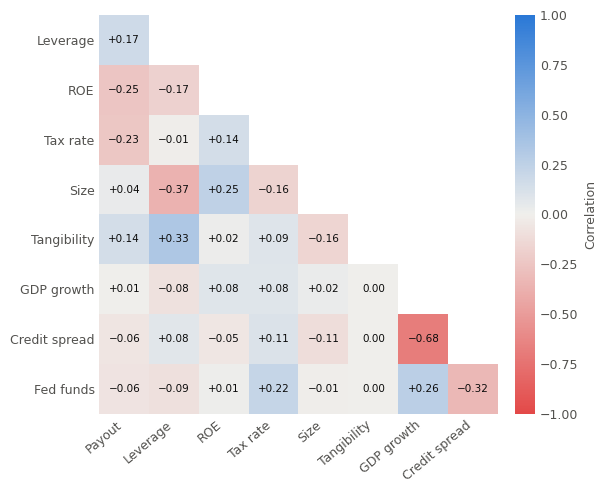

In [26]:
# Fig 1: correlation matrix of the main variables (lower triangle; red negative, blue positive)
NAMES = {"payout": "Payout", "lev": "Leverage", "roe": "ROE", "tax": "Tax rate", "size": "Size",
         "tangibility": "Tangibility", "gdp_growth": "GDP growth", "cred_spread": "Credit spread", "ffr": "Fed funds"}
cv = [c for c in NAMES if c in panel and panel[c].notna().any()]
corr = panel[cv].corr().to_numpy()
M = np.where(np.tril(np.ones_like(corr), -1).astype(bool), corr, np.nan)[1:, :-1]   # below the diagonal only
cmap = diverging(T)
fig, ax = plt.subplots(figsize=(6.5, 5.0))
im = ax.imshow(M, vmin=-1, vmax=1, cmap=cmap)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not np.isnan(M[i, j]):
            ax.text(j, i, minus(M[i, j], "+.2f"), ha="center", va="center", fontsize=7.5,
                    color=ink_on(cmap((M[i, j] + 1) / 2), T))                  # dark or white text, by the cell
ax.set_xticks(range(len(cv) - 1)); ax.set_xticklabels([NAMES[c] for c in cv[:-1]], rotation=40, ha="right")
ax.set_yticks(range(len(cv) - 1)); ax.set_yticklabels([NAMES[c] for c in cv[1:]])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, fraction=0.04, pad=0.03); cb.outline.set_visible(False); cb.ax.tick_params(length=0)
cb.set_label("Correlation", color=T["ink2"])
# full colour: a continuous scale would band in the 256-colour PNG
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_corr_heatmap.png", dpi=FIG_DPI, close=False, quantize=False); plt.show()

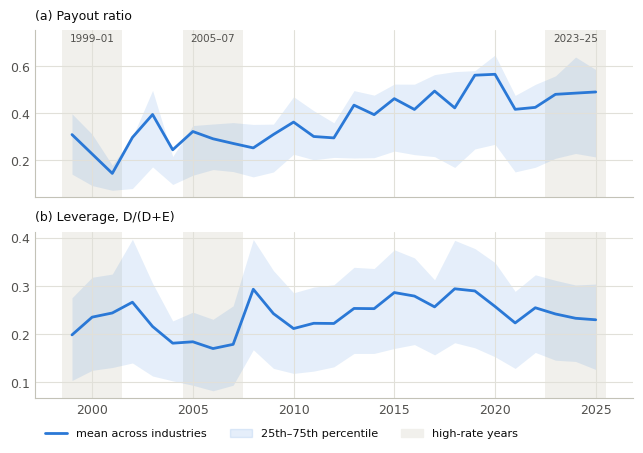

In [27]:
# Fig 2: payout and leverage over time, mean and interquartile range across industries, high-rate years in grey
years_ = sorted(panel["year"].unique())
episodes = runs(years_, [y in set(macro.loc[macro.high_rate == 1, "year"]) for y in years_])
fig, axes = plt.subplots(2, 1, figsize=(6.5, 4.6), sharex=True)
for ax, v, title in [(axes[0], "payout", "(a) Payout ratio"), (axes[1], "lev", "(b) Leverage, D/(D+E)")]:
    g = panel.groupby("year")[v]
    shade(ax, episodes, T, color=T["band"], alpha=1)
    ax.fill_between(years_, g.quantile(.25), g.quantile(.75), color=T["s1"], alpha=.12, lw=0)
    ax.plot(years_, g.mean(), color=T["s1"])
    ax.set_title(title)
ylo, yhi = axes[0].get_ylim(); axes[0].set_ylim(ylo, yhi + .12 * (yhi - ylo))   # headroom for the episode labels
for ep in episodes:
    axes[0].text((ep[0] + ep[-1]) / 2, .98, f"{ep[0]}–{str(ep[-1])[2:]}", transform=axes[0].get_xaxis_transform(),
                 ha="center", va="top", fontsize=7.5, color=T["ink2"])
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
axes[1].legend([Line2D([], [], color=T["s1"]), Patch(color=T["s1"], alpha=.12), Patch(color=T["band"])],
               ["mean across industries", "25th–75th percentile", "high-rate years"], loc="upper left", ncol=3,
               bbox_to_anchor=(0, -0.12))
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_payout_leverage_ts.png", dpi=FIG_DPI, close=False); plt.show()

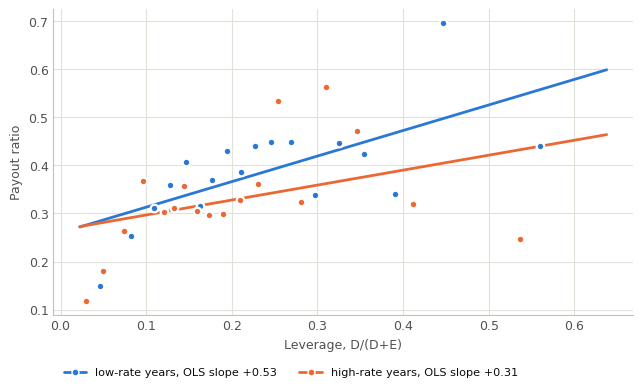

In [28]:
# Fig 3 (the key H2 picture): payout against leverage in low- and high-rate years, industry-years binned by
# leverage, with the pooled linear fit. Descriptive: no fixed effects, no controls.
def binscatter(ax, d, x, y, color, nbins=18):
    """Bin means of y by quantiles of x (dots) and the OLS line through the raw points; returns the slope."""
    d = d[[x, y]].dropna(); q = min(nbins, d[x].nunique())
    d = d.assign(_b=pd.qcut(d[x], q, duplicates="drop"))
    g = d.groupby("_b", observed=True).agg(xx=(x, "mean"), yy=(y, "mean"))
    b = np.polyfit(d[x], d[y], 1); xs = np.linspace(d[x].min(), d[x].max(), 50)
    ax.plot(xs, np.polyval(b, xs), color=color, lw=2, zorder=2)
    dot(ax, g["xx"], g["yy"], color, T, size=30)
    return b[0]
fig, ax = plt.subplots(figsize=(6.5, 4.0))
from matplotlib.lines import Line2D
handles, labels = [], []
for flag, color, lab in [(0, T["s1"], "low-rate years"), (1, T["s2"], "high-rate years")]:
    slope = binscatter(ax, panel[panel.high_rate == flag], "lev", "payout", color)
    handles.append(Line2D([], [], color=color, lw=2, marker="o", ms=5, mec=T["surface"]))
    labels.append(f"{lab}, OLS slope {minus(slope)}")
ax.set_xlabel("Leverage, D/(D+E)"); ax.set_ylabel("Payout ratio")
ax.legend(handles, labels, loc="upper left", ncol=2, bbox_to_anchor=(0, -0.14))
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_payout_vs_leverage_by_regime.png", dpi=FIG_DPI, close=False)
plt.show()

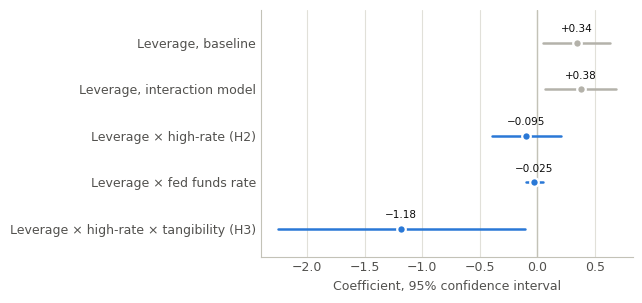

In [29]:
# Fig 4: the key coefficients with 95% CI (industry-clustered SE); hypothesis terms in blue, the rest in grey
def grab(res, key, label, hyp):
    """(label, estimate, CI low, CI high, is a hypothesis term), or None if the model or term is missing."""
    if res is None or not hasattr(res, "params") or key not in res.params: return None
    b = res.params[key]; se = res.std_errors[key]; return (label, b, b - 1.96 * se, b + 1.96 * se, hyp)
specs = [grab(res_base, "lev", "Leverage, baseline", False), grab(res_int, "lev", "Leverage, interaction model", False),
         grab(res_int, "lev_x_high", "Leverage × high-rate (H2)", True),
         grab(res_cont, "lev_x_ffr", "Leverage × fed funds rate", True),
         grab(res_h3, "lev_x_high_x_tang", "Leverage × high-rate × tangibility (H3)", True)
         if "res_h3" in globals() else None]
specs = [s for s in specs if s]
fig, ax = plt.subplots(figsize=(6.5, 0.42 * len(specs) + 1.0))
ax.axvline(0, color=T["base"], lw=1)
for i, (lab, b, lo, hi, hyp) in enumerate(specs):
    c = T["s1"] if hyp else T["dim"]
    ax.plot([lo, hi], [i, i], color=c, lw=1.8)
    dot(ax, b, i, c, T, size=38)
    # value label: three decimals for small coefficients, so the fed-funds term does not print as 0.00
    ax.text(b, i - 0.18, minus(b, "+.3f" if abs(b) < .1 else "+.2f"), ha="center", va="bottom", fontsize=7.5, color=T["ink"])
ax.set_yticks(range(len(specs))); ax.set_yticklabels([s[0] for s in specs]); ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.set_ylim(len(specs) - 0.4, -0.7)
ax.set_xlabel("Coefficient, 95% confidence interval")
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_coefficient_forest.png", dpi=FIG_DPI, close=False); plt.show()

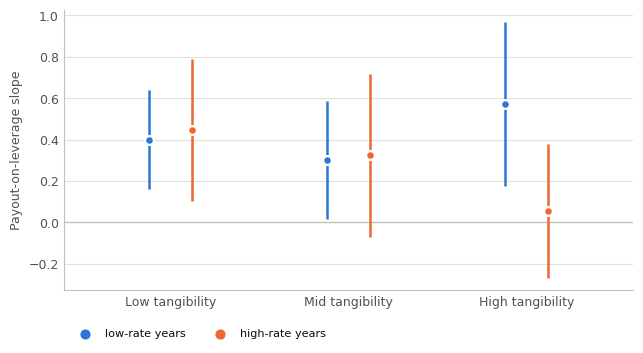

In [30]:
# Fig 5 (H3, descriptive): the payout-on-leverage slope in each tangibility tercile and rate regime, from a
# simple OLS within each cell (heteroskedasticity-robust SE; no fixed effects)
import statsmodels.formula.api as smf
if panel["tangibility"].notna().any():
    panel["tang_grp"] = pd.qcut(panel["tangibility"], 3, labels=["low", "mid", "high"], duplicates="drop")
    cells = []
    for g in ["low", "mid", "high"]:
        for hr, lab in [(0, "low-rate"), (1, "high-rate")]:
            sub = panel[(panel.tang_grp == g) & (panel.high_rate == hr)][["payout", "lev"]].dropna()
            if len(sub) > 10:
                m = smf.ols("payout ~ lev", sub).fit(cov_type="HC1")
                cells.append((g, lab, m.params["lev"], m.bse["lev"]))
    cdf = pd.DataFrame(cells, columns=["tang", "regime", "slope", "se"])
    groups = ["low", "mid", "high"]; x = np.arange(len(groups))
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.axhline(0, color=T["base"], lw=1)
    for k, (reg, col) in enumerate([("low-rate", T["s1"]), ("high-rate", T["s2"])]):
        s = cdf[cdf.regime == reg].set_index("tang").reindex(groups)
        xs = x + (k - .5) * 0.24                                         # the two regimes side by side
        ax.vlines(xs, s["slope"] - 1.96 * s["se"], s["slope"] + 1.96 * s["se"], color=col, lw=1.8)
        dot(ax, xs, s["slope"], col, T, size=40)
    ax.set_xticks(x); ax.set_xticklabels([f"{g.capitalize()} tangibility" for g in groups])
    ax.grid(axis="x", visible=False); ax.set_xlim(-0.6, len(groups) - 0.4)
    ax.set_ylabel("Payout-on-leverage slope")
    h1 = ax.scatter([], [], s=40, color=T["s1"]); h2 = ax.scatter([], [], s=40, color=T["s2"])
    ax.legend([h1, h2], ["low-rate years", "high-rate years"], loc="upper left", ncol=2, bbox_to_anchor=(0, -0.1))
    fig.tight_layout(); save_fig(fig, OUTDIR / "fig_H3_slopes_by_tangibility.png", dpi=FIG_DPI, close=False)
    plt.show()

## 12 · Reproducibility & outputs  <span style="color:gray">(Appendices B & D)</span>

In [31]:
# Appendix B (industry persistence and the rename map), the analysis panel itself, and the package versions of this
# run (Appendix D).
appendix_B = (persist.rename("years_present").reset_index()
              .assign(in_core=lambda d: d["industry"].isin(CORE)))
appendix_B.to_csv(OUTDIR / "appendix_B_industry_persistence.csv", index=False)
pd.Series(INDUSTRY_RENAME, name="canonical").rename_axis("original").to_csv(OUTDIR / "appendix_B_rename_map.csv")

panel.to_csv(OUTDIR / "analysis_panel.csv", index=False)
try: panel.to_parquet(OUTDIR / "analysis_panel.parquet", index=False)
except Exception: pass           # parquet needs pyarrow, which is optional

print(f"Saved {len(list(OUTDIR.glob('*')))} files to {OUTDIR}/\n")
print(f"Panel: {panel['industry'].nunique()} industries x {panel['year'].nunique()} years "
      f"({panel.year.min()}-{panel.year.max()}) = {len(panel)} obs; core = {len(CORE)} industries\n")
for m in ["pandas", "numpy", "matplotlib", "statsmodels", "linearmodels", "xlrd"]:
    try: print(f"  {m:13s}", __import__(m).__version__)
    except Exception: print(f"  {m:13s} (missing)")
print("  python       ", sys.version.split()[0])

Saved 34 files to outputs/

Panel: 140 industries x 27 years (1999-2025) = 2116 obs; core = 46 industries

  pandas        3.0.2
  numpy         2.4.4
  matplotlib    3.10.9
  statsmodels   0.15.0
  linearmodels  7.0
  xlrd          2.0.2
  python        3.11.15


---
### Summary

- **Full 1999–2025 industry panel** built reproducibly from the Damodaran archives (era-proof loader) plus
  FRED macro data. Sample: US non-financial, non-utility industries.
- **Hypotheses tested directly:** H1 in change form (do more levered industries cut dividends more in hiking
  years, §8b); H2 via the `lev × HighRate` interaction (primary regime = rate-level threshold; a 2022–25 dummy and
  the continuous rate as alternatives); H3 via the `lev × HighRate × tangibility` triple interaction.
- **Industry reconciliation** (Appendix B) handles Damodaran's 2012→2013 reclassification conservatively;
  a **stable-core sample** provides a robustness check on it.
- **Tangibility (H3)** is PP&E / total assets (within-year rank); the capex-based proxies are robustness checks.
- **Alternative leverage (§9d):** market leverage without leases, book leverage and Debt/EBITDA (debt relative
  to cash flow, also interacted with the fed funds rate as an interest-burden proxy).
- **H3 fragility (§10b):** the negative triple term stays negative without any single industry (significant at 5%
  in all but three cases), loses significance without the 2023–2025 episode (and, narrowly, without 2005–2007), and
  is not significant at 5% after adjusting for multiple testing: exploratory.
- **Data-quality fixes:** depreciation-based tangibility excluded in 2013–2015 (capex depreciation break);
  rows whose firm count does not match `divfund` (a shifted block in `wacc99`) set to missing;
  ratios with a non-positive denominator (payout when net income ≤ 0, Dividends/FCFE when FCFE ≤ 0, ROE whose sign
  contradicts net income, payouts that disagree with divfcfe's dividends / net income) set to missing;
  H3 includes the tangibility main effect; macro controls enter only the industry-FE-only specification.
- **Robustness (§9)** also drops the financial crisis (2008–09) and adds a growth / reinvestment control
  (capital spending intensity); neither changes the H2 null.
- **Power and bounds (§9b):** the H2 null is reported as a bound: the confidence interval rules out
  regime effects above a few payout points per SD of leverage, while smaller effects cannot be excluded.
- **Dividend smoothing (§8b):** dividends adjust slowly toward a target payout (Lintner), smoothing shows no
  detectable difference across rate regimes, and H1 tested in change form (dividend changes) is not supported either.
- **Tests** (`tests/`, no downloads): on fake Damodaran files with planted effects and planted data defects,
  this notebook recovers the effects and catches the defects; the package functions have unit tests.
- **Outputs** (`outputs/`): combined regression table (CSV + LaTeX), hypothesis verdicts, descriptive and
  proxy-robustness tables, the variable and industry appendices, and seven publication-ready figures.
- **Caveats to read in the thesis:** PP&E / assets changes definition in 2013 and 2016 (hence the ranks);
  the main leverage measure includes leases from 2013 on;
  industry-level aggregation; the data is a repeated cross-section; results are associational.